<div align="center">

# Facultad de Ciencias Exactas, Ingeniería y Agrimensura
## Universidad Nacional de Rosario (UNR)

---

# Aprendizaje Automático 1
## Trabajo Práctico: Predicción de precios de casas

**Integrantes:** _Cura Valentin, Cortinas Bautista, Maragliano Franco_

---
</div>

## Contenidos

1. Carga de datos y diccionario de variables
2. Análisis descriptivo
   - Diagnóstico y decisión sobre datos faltantes
   - Visualización: histogramas, boxplots, scatterplots
   - Lectura de cada variable (rango y comportamiento)
   - Outliers
   - Codificación de variables categóricas
   - Matriz de correlación
   - División train / validación / test
   - Estandarización
3. Regresión lineal múltiple
   - `LinearRegression` (solución analítica)
   - Descenso del gradiente: batch, estocástico y mini-batch
   - Regularización: Ridge, Lasso, Elastic Net
4. Optimización de hiperparámetros
5. Comparación de modelos
6. Conclusiones

In [1]:
# Dependencias. Se importa solo lo que se usa: el problema es de regresión, de modo
# que no intervienen clasificadores ni métodos de clustering.
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.metrics import (
    r2_score, mean_absolute_error, root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Semilla global: todos los splits e inicializaciones aleatorias la reutilizan
# para que el notebook sea reproducible de corrida a corrida.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Carga del dataset. Se busca el CSV junto al notebook (caso repositorio clonado)
# y, si no está, se recurre a la ruta de Colab. Evitamos dejar fija una ruta
# /content/... porque rompería al ejecutar el notebook desde el repositorio.
RUTA_CSV = "house-prices-tp.csv"
if not os.path.exists(RUTA_CSV):
    RUTA_CSV = "/content/sample_data/house-prices-tp.csv"

data = pd.read_csv(RUTA_CSV, sep=",")
print(f"Dataset cargado desde: {RUTA_CSV}")
print(f"Dimensiones: {data.shape[0]} filas x {data.shape[1]} columnas")

Dataset cargado desde: house-prices-tp.csv
Dimensiones: 556 filas x 14 columnas


## 1. Diccionario de variables

Características de entrada:

1. **CRIM**: tasa de criminalidad per cápita por ciudad
2. **ZN**: proporción de terrenos residenciales zonificados para lotes de más de 25.000 pies cuadrados
3. **INDUS**: proporción de acres de negocios no minoristas por ciudad
4. **CHAS**: variable dummy del río Charles (1 si el tramo limita con el río; 0 en caso contrario)
5. **NOX**: concentración de óxidos de nitrógeno (partes por 10 millones)
6. **RM**: número promedio de habitaciones por vivienda
7. **AGE**: proporción de unidades ocupadas por sus propietarios construidas antes de 1940
8. **DIS**: distancias ponderadas a cinco centros de empleo de Boston
9. **RAD**: índice de accesibilidad a las autopistas radiales
10. **TAX**: tasa de impuesto sobre la propiedad a valor completo por cada $10.000
11. **PTRATIO**: proporción alumno-maestro por ciudad
12. **B**: resultado de la ecuación $B = 1000(Bk - 0.63)^2$, con $Bk$ la proporción de negros por ciudad
13. **LSTAT**: porcentaje de población de menor estatus socioeconómico

Variable de salida (target):

14. **MEDV**: valor mediano de las viviendas ocupadas por sus propietarios, en miles de dólares

In [3]:
# Normalización de los nombres de columna: minúsculas, sin espacios ni puntuación.
# Homogeneizarlos ahora evita errores de tipeo en el resto del notebook.
data.columns = (
    data.columns.str.strip().str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     533 non-null    float64
 1   zn       534 non-null    float64
 2   indus    541 non-null    float64
 3   chas     533 non-null    float64
 4   nox      532 non-null    float64
 5   rm       535 non-null    float64
 6   age      532 non-null    float64
 7   dis      541 non-null    float64
 8   rad      528 non-null    float64
 9   tax      538 non-null    float64
 10  ptratio  528 non-null    float64
 11  b        534 non-null    float64
 12  lstat    534 non-null    float64
 13  medv     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [4]:
# Primeras filas y resumen estadístico. .T transpone para que cada variable sea una
# fila y la tabla se lea de corrido.
display(data.head())
display(data.describe().T)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


,count,mean,std,min,25%,50%,75%,max
crim,533.0,5.845517,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762
zn,534.0,13.197175,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000
indus,541.0,11.218725,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400
chas,533.0,0.090056,0.286531,0.00000,0.00000,0.000000,0.000000,1.0000
nox,532.0,0.560050,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710
rm,535.0,6.291839,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800
age,532.0,67.632303,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000
dis,541.0,3.944102,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265
rad,528.0,9.699379,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000
tax,538.0,409.575089,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000


## 2. Análisis descriptivo

### 2.1 Diagnóstico de datos faltantes

El primer paso es cuantificar dónde están los faltantes. El porcentaje por columna
no alcanza para decidir qué hacer: hay que mirar además cómo se distribuyen **por
fila**, porque eso determina si conviene descartar filas o imputarlas.

In [5]:
# Faltantes por columna, en valor absoluto y en porcentaje.
faltantes = pd.DataFrame({
    "n_faltantes": data.isna().sum(),
    "pct_faltantes": (data.isna().mean() * 100).round(2),
}).sort_values("n_faltantes", ascending=False)
display(faltantes)

# La faltancia está repartida de forma pareja entre las 14 columnas: ninguna se
# acerca a un porcentaje que justifique descartar la variable entera.
print(f"Faltantes por columna: mínimo {faltantes['n_faltantes'].min()}, "
      f"máximo {faltantes['n_faltantes'].max()}")

,n_faltantes,pct_faltantes
ptratio,28,5.04
rad,28,5.04
nox,24,4.32
age,24,4.32
chas,23,4.14
crim,23,4.14
lstat,22,3.96
b,22,3.96
zn,22,3.96
rm,21,3.78


Faltantes por columna: mínimo 15, máximo 28


In [6]:
# Distribución de faltantes POR FILA. Es la vista que decide la estrategia.
n_faltantes_fila = data.isna().sum(axis=1)
incompletas = n_faltantes_fila > 0

print("Cantidad de NaN por fila:")
print(n_faltantes_fila.value_counts().sort_index().to_string())
print()
print(f"Filas completas          : {(~incompletas).sum()}")
print(f"Filas con algún faltante : {incompletas.sum()} de {len(data)} "
      f"({100 * incompletas.mean():.2f}%)")

Cantidad de NaN por fila:
0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1

Filas completas          : 506
Filas con algún faltante : 50 de 556 (8.99%)


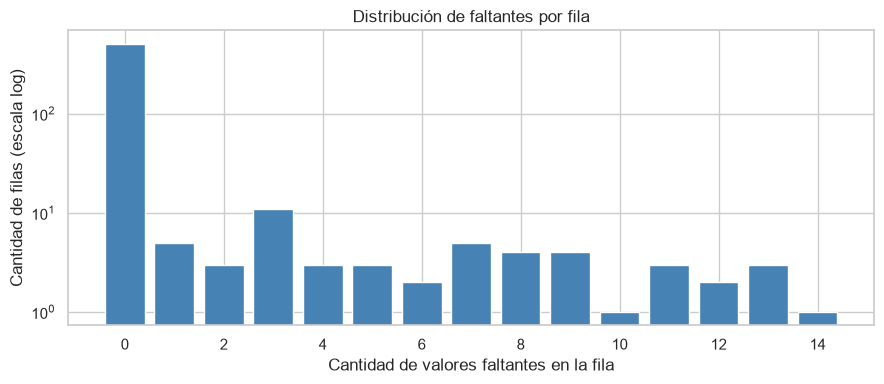

In [7]:
# La distribución anterior no decae: hay filas a las que les faltan 12, 13 y hasta
# las 14 columnas. Un proceso natural de pérdida de datos se concentra en 1 o 2
# faltantes por fila; este patrón es casi uniforme entre 1 y 14, lo que sugiere que
# la faltancia fue introducida artificialmente y no observada.
fig, ax = plt.subplots(figsize=(9, 4))
conteo = n_faltantes_fila.value_counts().sort_index()
ax.bar(conteo.index, conteo.values, color="steelblue")
ax.set_yscale("log")   # escala log: si no, las filas completas aplastan al resto
ax.set_xlabel("Cantidad de valores faltantes en la fila")
ax.set_ylabel("Cantidad de filas (escala log)")
ax.set_title("Distribución de faltantes por fila")
plt.tight_layout()
plt.show()

### 2.2 ¿Son observaciones reales o registros corrompidos?

La decisión de imputar o descartar depende de qué son estas filas. Si son
observaciones reales a las que se les perdió un dato, imputar recupera información.
Si son registros corrompidos, imputar **fabrica** observaciones y las introduce al
modelo como si fueran mediciones.

Para distinguir un caso del otro buscamos un criterio que dependa únicamente de este
dataset. `rad` (índice de accesibilidad) y `tax` (tasa por cada $10.000) toman
**solo valores enteros** en todas las filas completas. No lo asumimos por
conocimiento del dominio: lo verificamos sobre los datos. Un valor con decimales en
esas columnas es, entonces, un valor que el dataset nunca produce.

In [8]:
# Verificamos qué columnas son enteras en las filas completas. Son el único
# "detector" disponible: una variable continua corrompida es indistinguible.
print("¿Entera en todas las filas completas?")
enteras = []
for col in data.columns:
    if (data.loc[~incompletas, col] % 1 == 0).all():
        enteras.append(col)
        print(f"  {col:8s} -> SÍ")

# chas aparece en la lista por ser una dummy, pero no sirve como detector: toma
# valores 0 y 1 tanto en las filas completas como en las incompletas, de modo que
# nunca puede delatar un valor imposible. El criterio se apoya solo en rad y tax,
# que son índices con rango amplio.
print()
for col in enteras:
    fuera = (data.loc[incompletas, col].dropna() % 1 != 0).sum()
    print(f"  {col:8s}: {fuera} valores no enteros entre las filas incompletas "
          f"(rango observado: {data[col].min():.0f} a {data[col].max():.0f})")

¿Entera en todas las filas completas?
  chas     -> SÍ
  rad      -> SÍ
  tax      -> SÍ

  chas    : 0 valores no enteros entre las filas incompletas (rango observado: 0 a 1)
  rad     : 22 valores no enteros entre las filas incompletas (rango observado: 1 a 24)
  tax     : 32 valores no enteros entre las filas incompletas (rango observado: 187 a 711)


In [9]:
# Marcamos como contaminada toda fila con un valor OBSERVADO imposible, es decir,
# un decimal en rad o en tax.
contaminada = (
    (data["rad"].notna() & (data["rad"] % 1 != 0)) |
    (data["tax"].notna() & (data["tax"] % 1 != 0))
)

# Cruzamos gravedad (cuántos faltantes tiene la fila) contra contaminación. La
# hipótesis a testear es que las filas con pocos faltantes conservan información
# confiable y que por lo tanto conviene imputarlas.
tabla = pd.DataFrame({
    "filas": n_faltantes_fila[incompletas].value_counts(),
    "contaminadas": n_faltantes_fila[incompletas & contaminada].value_counts(),
}).fillna(0).astype(int).sort_index()
tabla["pct"] = (100 * tabla["contaminadas"] / tabla["filas"]).round(0)
tabla.index.name = "n_NaN"
display(tabla)

,filas,contaminadas,pct
n_NaN,,,
1,5,5,100.0
2,3,3,100.0
3,11,9,82.0
4,3,3,100.0
5,3,2,67.0
6,2,2,100.0
7,5,3,60.0
8,4,4,100.0
9,4,3,75.0


In [10]:
# Una fila es auditable si conserva AL MENOS UNA de las dos columnas enteras:
# con una sola alcanza para detectar un valor imposible. Solo quedan fuera del
# test las filas en las que rad y tax están ambas ausentes.
auditable = incompletas & (data["rad"].notna() | data["tax"].notna())

print(f"Filas incompletas                    : {incompletas.sum()}")
print(f"  auditables (rad o tax presente)    : {auditable.sum()}")
print(f"    de ellas, contaminadas           : {(auditable & contaminada).sum()}")
print(f"    de ellas, limpias                : {(auditable & ~contaminada).sum()}")
print(f"  no auditables (ambas ausentes)     : {(incompletas & ~auditable).sum()}")

# El target nunca se imputa: predecir medv a partir de un medv inventado es
# circular y contamina la evaluación del modelo. Verificamos que las filas sin
# target sean un subconjunto de las incompletas (se miran solo esas filas).
sin_target = data["medv"].isna()
print()
print(f"Filas sin target 'medv': {sin_target.sum()}")
print(f"  ¿todas dentro del conjunto incompleto?: {incompletas[sin_target].all()}")

Filas incompletas                    : 50
  auditables (rad o tax presente)    : 38
    de ellas, contaminadas           : 38
    de ellas, limpias                : 0
  no auditables (ambas ausentes)     : 12

Filas sin target 'medv': 21
  ¿todas dentro del conjunto incompleto?: True


### 2.3 Decisión sobre los datos faltantes

El cruce entre gravedad y contaminación da vuelta la intuición inicial. Las filas
con **un solo** faltante son las que están contaminadas al 100%: lo que queda
observado en ellas tampoco es confiable. Las que aparecen limpias son justamente
aquellas a las que les faltan 12, 13 o 14 columnas, y aparecen limpias solo porque
`rad` y `tax` están entre las ausentes y el test no se les puede aplicar.

El resultado decisivo es que **de las filas incompletas auditables, el 100% tiene al
menos un valor observado imposible**. Ninguna fila incompleta pasó el test teniendo
el dato disponible.

Esto descarta la imputación. Imputar una fila con un único faltante parecería barato
—se completa un hueco y se recuperan trece datos—, pero esos trece datos no son
buenos: ya está probado que al menos uno es fabricado. La imputación produciría una
fila completa y falsa, indistinguible de una observación real para el modelo.

**Decisión: se eliminan las filas incompletas.** El criterio no es la ausencia de
datos en sí, sino la evidencia de corrupción; la ausencia es el síntoma que las
identifica. Se descartan además las filas sin `medv`, que no pueden usarse para
entrenar ni para evaluar, y que en este dataset ya están todas dentro del conjunto
incompleto.

**Limitación asumida:** `rad` y `tax` son las únicas dos variables enteras de
catorce, de modo que son el único detector disponible. Una fila alterada únicamente
en variables continuas no sería detectable por esta vía. Dado que la totalidad de
las filas auditables falló el test, inferimos que las restantes provienen del mismo
procedimiento.

In [11]:
# Aplicamos la decisión. Equivale a data.dropna(), escrito de forma explícita para
# dejar asentado que el filtro es por fila.
data_clean = data[data.isna().sum(axis=1) == 0].copy()

print(f"Dataset original : {len(data)} filas")
print(f"Filas eliminadas : {len(data) - len(data_clean)}")
print(f"Dataset final    : {len(data_clean)} filas")
print(f"Faltantes restantes: {data_clean.isna().sum().sum()}")

Dataset original : 556 filas
Filas eliminadas : 50
Dataset final    : 506 filas
Faltantes restantes: 0


In [12]:
# Guardamos la base depurada en un archivo NUEVO. El CSV original no se sobrescribe,
# de modo que la limpieza es reproducible y auditable desde los datos crudos.
RUTA_CSV_LIMPIO = os.path.join(os.path.dirname(RUTA_CSV), "house-prices-tp-clean.csv")
data_clean.to_csv(RUTA_CSV_LIMPIO, index=False)
print(f"Base limpia guardada en: {RUTA_CSV_LIMPIO}")

Base limpia guardada en: house-prices-tp-clean.csv


### 2.4 Visualización de las variables

Con el dataset ya depurado, revisamos el comportamiento y el rango de variación de
cada variable.

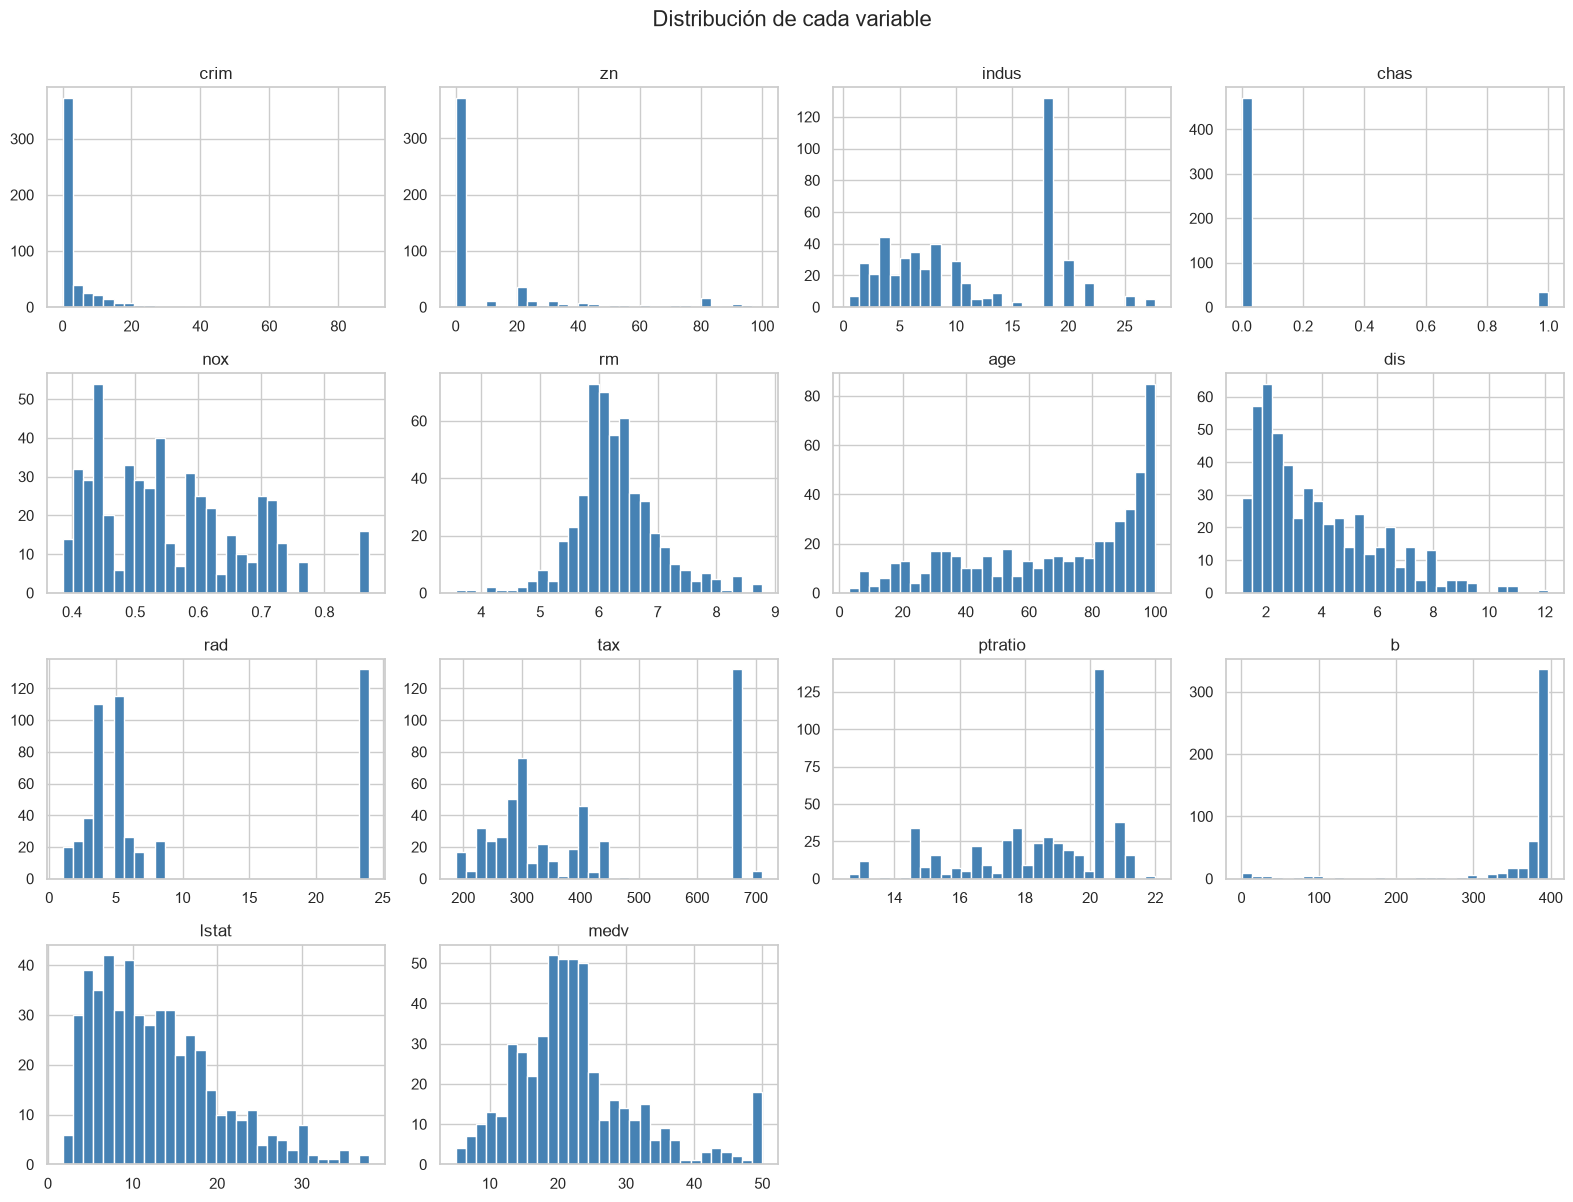

In [13]:
# Histogramas: forma de la distribución de cada variable. Interesa detectar
# asimetrías y variables concentradas en pocos valores, que condicionan el escalado.
data_clean.hist(bins=30, figsize=(16, 12), color="steelblue", edgecolor="white")
plt.suptitle("Distribución de cada variable", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

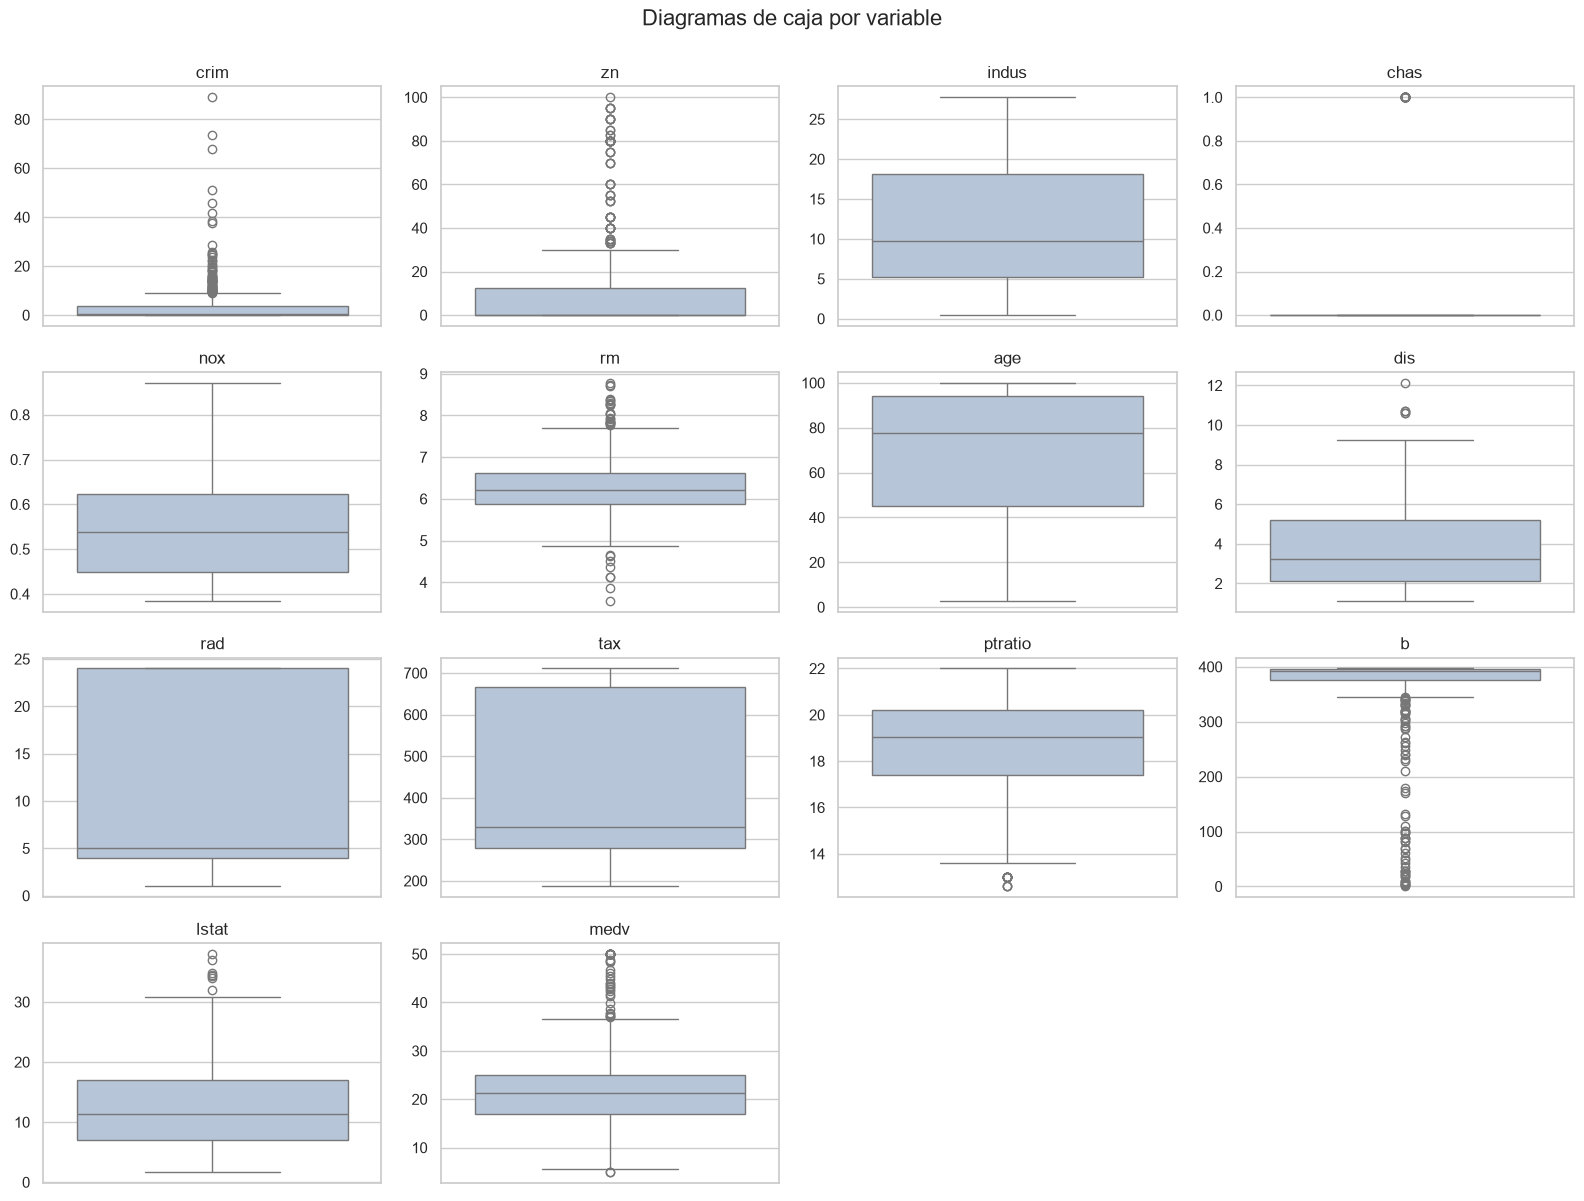

In [14]:
# Diagramas de caja: permiten leer mediana, dispersión y outliers. Se grafican en
# paneles separados porque las escalas son muy distintas entre variables (tax ronda
# los cientos, nox está por debajo de 1).
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), data_clean.columns):
    sns.boxplot(y=data_clean[col], ax=ax, color="lightsteelblue")
    ax.set_title(col)
    ax.set_ylabel("")
for ax in axes.ravel()[len(data_clean.columns):]:
    ax.axis("off")
plt.suptitle("Diagramas de caja por variable", fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [15]:
# Registramos numéricamente la asimetría que se ve en los gráficos anteriores.
asimetria = data_clean.skew().sort_values(ascending=False)
print("Coeficiente de asimetría (skewness) por variable:")
print(asimetria.round(2).to_string())

Coeficiente de asimetría (skewness) por variable:
crim       5.22
chas       3.41
zn         2.23
medv       1.11
dis        1.01
rad        1.00
lstat      0.91
nox        0.73
tax        0.67
rm         0.40
indus      0.30
age       -0.60
ptratio   -0.80
b         -2.89


In [16]:
# Resumen del rango de variación de cada variable. El valor más frecuente y su
# porcentaje muestran qué variables se concentran en pocos valores.
resumen = pd.DataFrame({
    "min": data_clean.min(),
    "max": data_clean.max(),
    "mediana": data_clean.median(),
    "media": data_clean.mean(),
    "desvio": data_clean.std(),
    "valores_unicos": data_clean.nunique(),
    "valor_mas_frecuente": data_clean.mode().iloc[0],
    "pct_mas_frecuente": [100 * (data_clean[c] == data_clean[c].mode().iloc[0]).mean()
                          for c in data_clean.columns],
})
display(resumen.round(2))

,min,max,mediana,media,desvio,valores_unicos,valor_mas_frecuente,pct_mas_frecuente
crim,0.01,88.98,0.26,3.61,8.60,504,0.02,0.40
zn,0.00,100.00,0.00,11.36,23.32,26,0.00,73.52
indus,0.46,27.74,9.69,11.14,6.86,76,18.10,26.09
chas,0.00,1.00,0.00,0.07,0.25,2,0.00,93.08
nox,0.38,0.87,0.54,0.55,0.12,81,0.54,4.55
rm,3.56,8.78,6.21,6.28,0.70,446,5.71,0.59
age,2.90,100.00,77.50,68.57,28.15,356,100.00,8.50
dis,1.13,12.13,3.21,3.80,2.11,412,3.50,0.99
rad,1.00,24.00,5.00,9.55,8.71,9,24.00,26.09
tax,187.00,711.00,330.00,408.24,168.54,66,666.00,26.09


#### Lectura de cada variable

| Variable | Rango | Comportamiento |
|---|---|---|
| `crim` | 0.006 – 89 | Muy asimétrica a la derecha (la más asimétrica del dataset): dos tercios de las zonas tienen criminalidad menor a 1 y unas pocas superan 20. |
| `zn` | 0 – 100 | El 73.5% de las zonas vale 0 (no tiene terrenos residenciales grandes); el resto se reparte en pocos valores. |
| `indus` | 0.46 – 27.7 | Bimodal: un grupo de zonas poco industriales y otro concentrado en 18.1 (132 filas). |
| `chas` | 0 / 1 | Binaria y desbalanceada: solo 35 de 506 zonas (7%) limitan con el río. |
| `nox` | 0.385 – 0.871 | Leve asimetría a la derecha; varía en un rango angosto. |
| `rm` | 3.6 – 8.8 | La más parecida a una normal, centrada en 6.2 habitaciones, con colas hacia ambos lados. |
| `age` | 2.9 – 100 | Asimétrica a la izquierda: un tercio de las zonas tiene 90% o más de viviendas anteriores a 1940. |
| `dis` | 1.1 – 12.1 | Asimétrica a la derecha: la mayoría de las zonas está cerca de los centros de empleo. |
| `rad` | 1 – 24 | Discreta, con solo 9 valores: la mayoría entre 1 y 8, y un bloque de 132 filas en 24, sin valores intermedios. |
| `tax` | 187 – 711 | Bimodal: las mismas 132 filas de `rad = 24` tienen `tax = 666`, lo que explica la fuerte correlación entre ambas. |
| `ptratio` | 12.6 – 22 | Asimétrica a la izquierda, con un pico en 20.2 (140 filas). |
| `b` | 0.32 – 396.9 | Muy asimétrica a la izquierda: más de la mitad de las zonas está cerca del máximo, y unas pocas muy por debajo. |
| `lstat` | 1.7 – 38 | Asimetría a la derecha moderada, centrada en 11%. |
| `medv` | 5 – 50 | Target. Asimétrica a la derecha, mediana de 21.2 k$. 16 viviendas valen exactamente 50: es un **tope** del registro (el valor real es 50 o más), no un precio medido. |

**Qué implica para el modelado.** Las escalas son muy distintas entre variables, lo
que obliga a estandarizar (sección 2.8). Varias variables están concentradas en pocos
valores (`zn`, `rad`, `tax`, `chas`) o son muy asimétricas (`crim`, `b`), lo que
anticipa que una relación puramente lineal con el precio no va a ser perfecta.

#### Outliers

Los diagramas de caja muestran valores fuera de los bigotes en varias variables.
Antes de decidir qué hacer con ellos, los cuantificamos.

In [17]:
# Outliers según el criterio de los boxplots: valores a más de 1.5 veces el rango
# intercuartílico (IQR) por debajo del primer cuartil o por encima del tercero.
q1 = data_clean.quantile(0.25)
q3 = data_clean.quantile(0.75)
iqr = q3 - q1
es_outlier = (data_clean < q1 - 1.5 * iqr) | (data_clean > q3 + 1.5 * iqr)

outliers = pd.DataFrame({
    "n_outliers": es_outlier.sum(),
    "pct": (100 * es_outlier.mean()).round(1),
}).sort_values("n_outliers", ascending=False)
display(outliers)

# chas se excluye del conteo por fila: al ser binaria, todos sus "outliers" son
# simplemente los 1.
filas_con_outlier = es_outlier.drop(columns=["chas"]).any(axis=1)
print(f"Filas con al menos un outlier (sin contar chas): {filas_con_outlier.sum()} "
      f"de {len(data_clean)} ({100 * filas_con_outlier.mean():.1f}%)")
print(f"Viviendas con medv en el tope de 50 k$: {(data_clean['medv'] == 50).sum()}")

,n_outliers,pct
b,77,15.2
zn,68,13.4
crim,66,13.0
medv,40,7.9
chas,35,6.9
rm,30,5.9
ptratio,15,3.0
lstat,7,1.4
dis,5,1.0
indus,0,0.0


Filas con al menos un outlier (sin contar chas): 218 de 506 (43.1%)
Viviendas con medv en el tope de 50 k$: 16


**Decisión sobre los outliers: se mantienen.**

- **Son valores reales, no errores.** A diferencia de las filas eliminadas en 2.3, no
  hay evidencia de corrupción: todos están dentro de rangos posibles (una zona con
  criminalidad alta, una vivienda con 8 habitaciones, una casa de 50 k$). Son parte
  del fenómeno que el modelo tiene que aprender.
- **Varios son un efecto de la forma de la distribución, no valores anómalos.** En
  `zn`, `chas` y `b` la mayoría de las observaciones se concentra en un único valor o
  muy cerca de él, el rango intercuartílico queda angosto y cualquier valor distinto
  aparece como "outlier".
- **Eliminarlos sería muy costoso.** Más del 40% de las filas tiene al menos un valor
  fuera de los bigotes; descartarlas dejaría el dataset en poco más de la mitad.
- **No se recortan ni se transforman** para mantener los valores en sus unidades
  originales y los coeficientes interpretables. Se asume como limitación que los
  valores extremos pesan más en el MSE; por eso se reporta también el MAE, que es
  menos sensible a ellos.

### 2.5 Codificación de variables categóricas

El dataset es enteramente numérico. La única variable categórica es `chas`, que ya
viene expresada como variable dummy (1 si el tramo limita con el río Charles, 0 en
caso contrario), de modo que **no requiere codificación adicional**: aplicarle
one-hot encoding generaría una columna redundante y linealmente dependiente de la
primera.

`rad` es un índice de accesibilidad con valores enteros. Podría tratarse como
ordinal, pero al ser un índice creciente su representación numérica ya preserva el
orden, y es la que usamos.

In [18]:
# Verificamos que chas efectivamente sea binaria antes de darla por codificada.
print("Valores únicos de 'chas':", sorted(data_clean["chas"].unique().tolist()))
print("Distribución:")
print(data_clean["chas"].value_counts().to_string())

Valores únicos de 'chas': [0.0, 1.0]
Distribución:
chas
0.0    471
1.0     35


### 2.6 Matriz de correlación

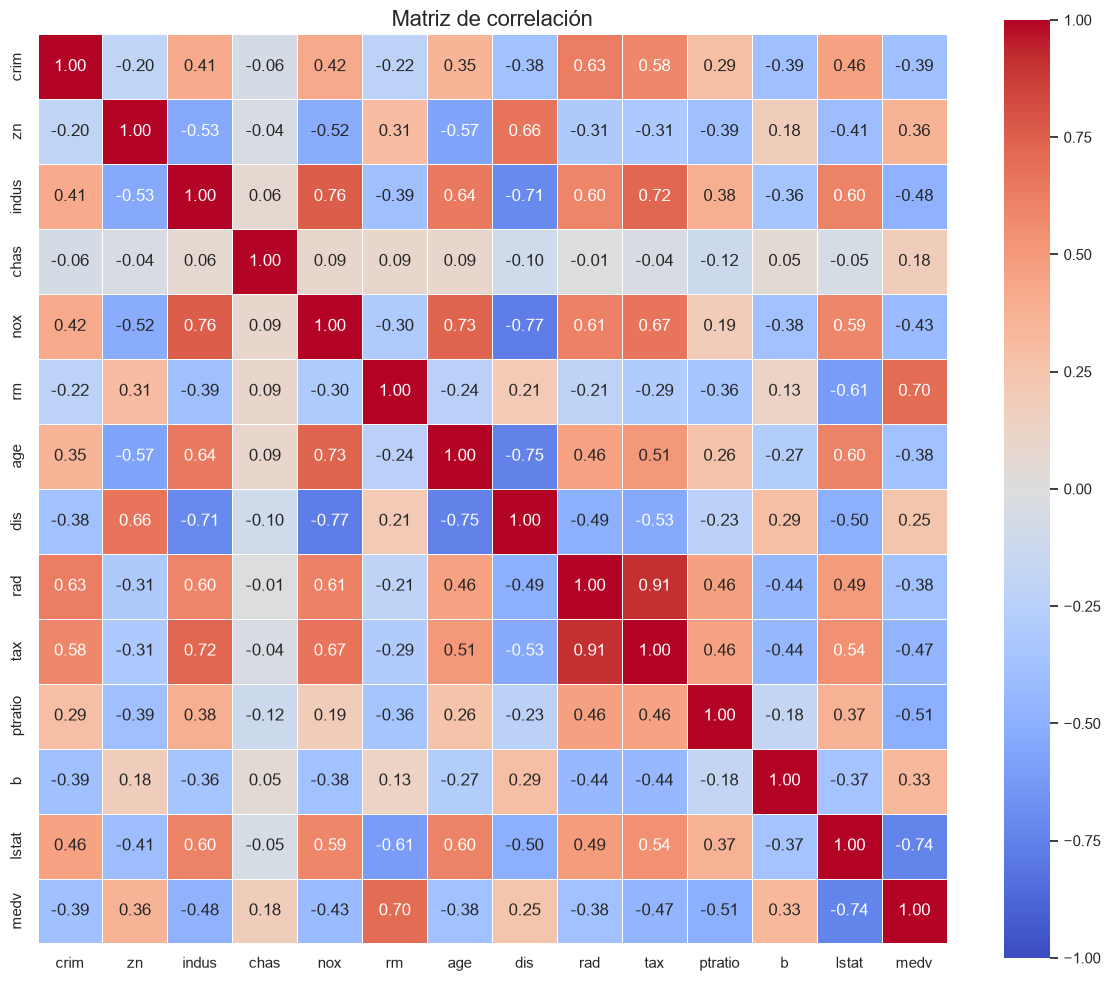

In [19]:
# Correlación lineal entre todas las variables. Sirve para dos cosas: identificar
# qué predictores se asocian con el target, y detectar colinealidad entre
# predictores, que es justamente lo que la regularización mitiga.
corr_matrix = data_clean.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Matriz de correlación", fontsize=16)
plt.tight_layout()
plt.show()

In [20]:
# Correlación de cada predictor con el target, ordenada por magnitud.
corr_target = corr_matrix["medv"].drop("medv").sort_values(key=abs, ascending=False)
print("Correlación con medv (ordenada por valor absoluto):")
print(corr_target.round(3).to_string())

# Pares de predictores fuertemente correlacionados entre sí (colinealidad).
print("\nPares de predictores con |correlación| > 0.7:")
pred = corr_matrix.drop(index="medv", columns="medv")
for i in range(len(pred.columns)):
    for j in range(i + 1, len(pred.columns)):
        c = pred.iloc[i, j]
        if abs(c) > 0.7:
            print(f"  {pred.columns[i]:8s} - {pred.columns[j]:8s}: {c:+.3f}")

Correlación con medv (ordenada por valor absoluto):
lstat     -0.738
rm         0.695
ptratio   -0.508
indus     -0.484
tax       -0.469
nox       -0.427
crim      -0.388
rad       -0.382
age       -0.377
zn         0.360
b          0.333
dis        0.250
chas       0.175

Pares de predictores con |correlación| > 0.7:
  indus    - nox     : +0.764
  indus    - dis     : -0.708
  indus    - tax     : +0.721
  nox      - age     : +0.731
  nox      - dis     : -0.769
  age      - dis     : -0.748
  rad      - tax     : +0.910


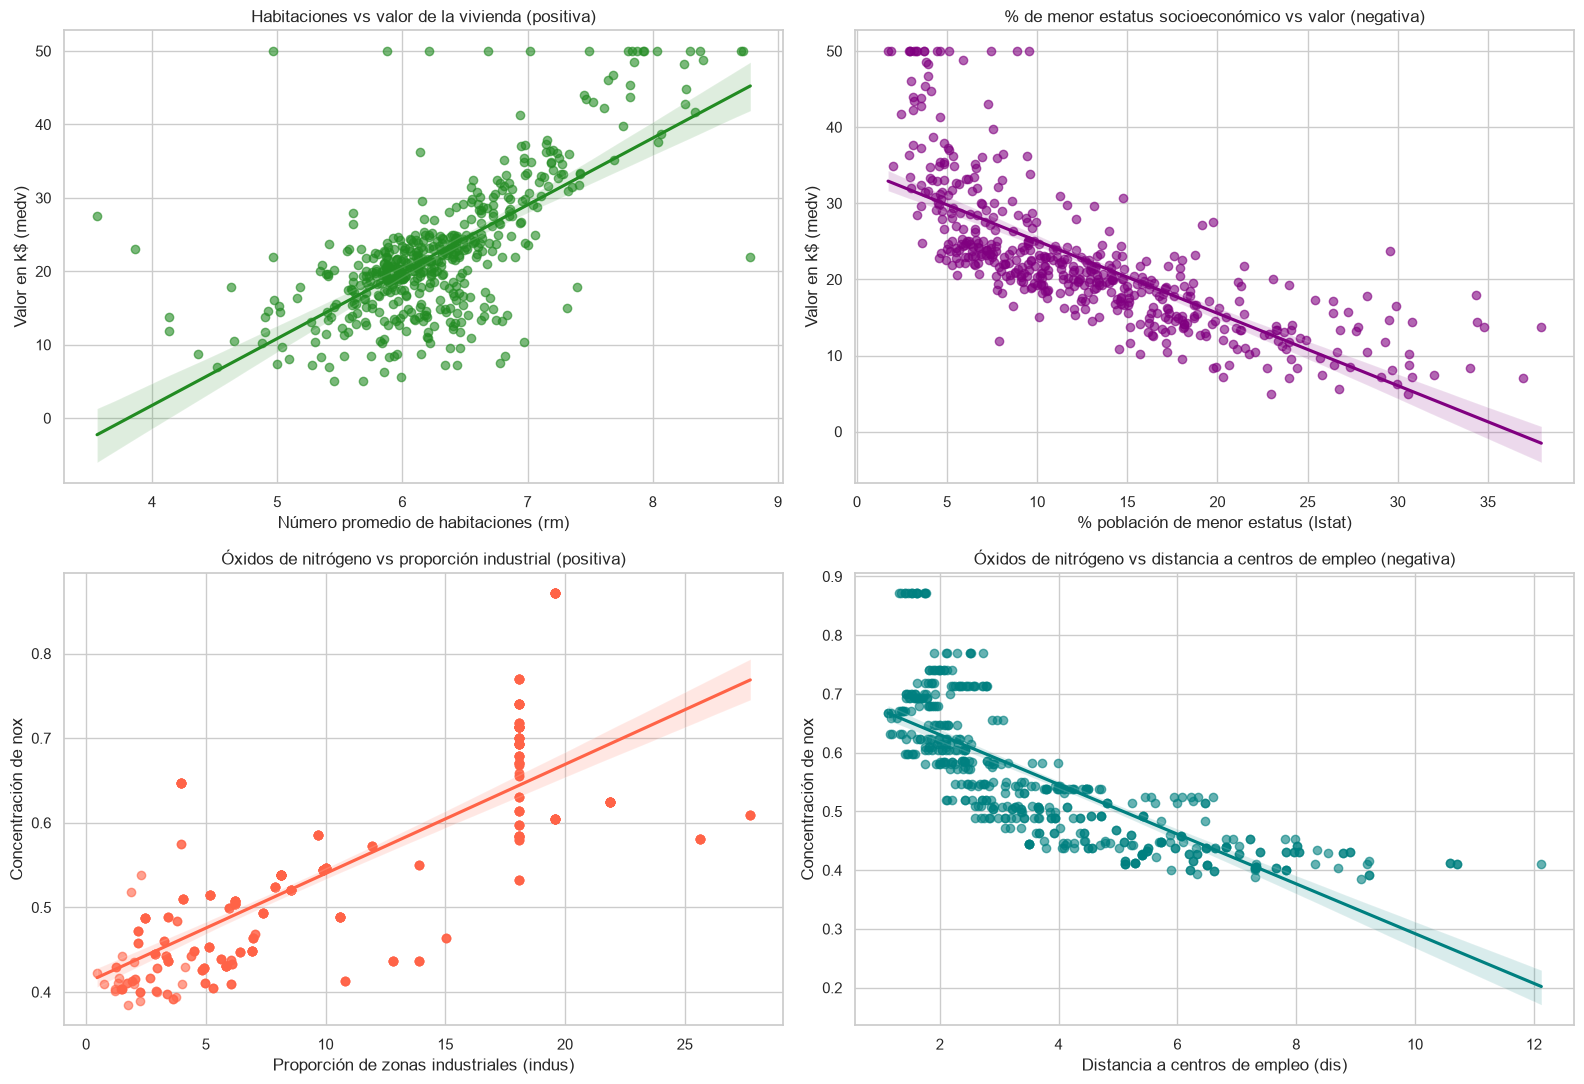

In [21]:
# Graficamos las relaciones más marcadas que surgen de la matriz: las dos de mayor
# correlación con el target y dos entre predictores.
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.regplot(data=data_clean, x="rm", y="medv", ax=axes[0, 0],
            color="forestgreen", scatter_kws={"alpha": 0.6})
axes[0, 0].set_title("Habitaciones vs valor de la vivienda (positiva)")
axes[0, 0].set_xlabel("Número promedio de habitaciones (rm)")
axes[0, 0].set_ylabel("Valor en k$ (medv)")

sns.regplot(data=data_clean, x="lstat", y="medv", ax=axes[0, 1],
            color="purple", scatter_kws={"alpha": 0.6})
axes[0, 1].set_title("% de menor estatus socioeconómico vs valor (negativa)")
axes[0, 1].set_xlabel("% población de menor estatus (lstat)")
axes[0, 1].set_ylabel("Valor en k$ (medv)")

sns.regplot(data=data_clean, x="indus", y="nox", ax=axes[1, 0],
            color="tomato", scatter_kws={"alpha": 0.6})
axes[1, 0].set_title("Óxidos de nitrógeno vs proporción industrial (positiva)")
axes[1, 0].set_xlabel("Proporción de zonas industriales (indus)")
axes[1, 0].set_ylabel("Concentración de nox")

sns.regplot(data=data_clean, x="dis", y="nox", ax=axes[1, 1],
            color="teal", scatter_kws={"alpha": 0.6})
axes[1, 1].set_title("Óxidos de nitrógeno vs distancia a centros de empleo (negativa)")
axes[1, 1].set_xlabel("Distancia a centros de empleo (dis)")
axes[1, 1].set_ylabel("Concentración de nox")

plt.tight_layout()
plt.show()

### 2.7 División en entrenamiento, validación y prueba

Separamos los datos **antes** de escalar y de entrenar cualquier modelo. El orden
importa: si el escalador se ajustara con el dataset completo, la media y el desvío
del conjunto de prueba se filtrarían al entrenamiento (fuga de datos) y las métricas
de test dejarían de medir generalización.

Usamos una partición 70 / 10 / 20. El conjunto de validación es necesario porque las
implementaciones de descenso del gradiente lo usan para graficar la evolución del
error época a época sin tocar el conjunto de prueba.

In [22]:
# Separación de predictores y target.
X = data_clean.drop(columns=["medv"])
y = data_clean["medv"]

# Primera partición: 80% para entrenamiento+validación, 20% para prueba.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Segunda partición: del 80% anterior, un 12.5% va a validación (= 10% del total).
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]} filas ({100*len(X_train)/len(X):.0f}%)")
print(f"Validación   : {X_val.shape[0]} filas ({100*len(X_val)/len(X):.0f}%)")
print(f"Prueba       : {X_test.shape[0]} filas ({100*len(X_test)/len(X):.0f}%)")

Entrenamiento: 353 filas (70%)
Validación   : 51 filas (10%)
Prueba       : 102 filas (20%)


### 2.8 Estandarización

Las variables tienen escalas muy dispares: `tax` va de 187 a 711 mientras que `nox`
se mueve entre 0.385 y 0.871. Esto afecta a dos de los métodos que vamos a usar:

- **Descenso del gradiente**: con escalas dispares la superficie de costo queda muy
  alargada y el algoritmo necesita una tasa de aprendizaje diminuta para no divergir.
- **Regularización**: Ridge, Lasso y Elastic Net penalizan la magnitud de los
  coeficientes. Sin estandarizar, la penalización castiga más a las variables
  medidas en unidades pequeñas, que necesitan coeficientes grandes para compensar.

El escalador se ajusta **solo con el conjunto de entrenamiento** y luego se aplica a
validación y prueba.

In [23]:
# StandardScaler: (x - media) / desvío. Se ajusta con train y se aplica al resto.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Media y desvío por variable DESPUÉS de escalar (entrenamiento):")
print(pd.DataFrame({
    "media": X_train_scaled.mean(axis=0).round(3),
    "desvio": X_train_scaled.std(axis=0).round(3),
}, index=X.columns).to_string())

Media y desvío por variable DESPUÉS de escalar (entrenamiento):
         media  desvio
crim      -0.0     1.0
zn         0.0     1.0
indus      0.0     1.0
chas       0.0     1.0
nox       -0.0     1.0
rm         0.0     1.0
age       -0.0     1.0
dis        0.0     1.0
rad        0.0     1.0
tax        0.0     1.0
ptratio    0.0     1.0
b         -0.0     1.0
lstat      0.0     1.0


## 3. Regresión lineal múltiple

### 3.1 `LinearRegression`

`LinearRegression` resuelve el problema por mínimos cuadrados ordinarios, es decir
mediante la solución analítica $W = (X^TX)^{-1}X^Ty$. No itera: obtiene el óptimo
exacto en un paso.

In [24]:
# Función auxiliar para calcular el mismo conjunto de métricas en todos los modelos.
# Se evalúa en train y en test: comparar ambos es lo único que permite distinguir un
# modelo con alto sesgo (malo en los dos) de uno con alta varianza (excelente en
# train, malo en test).
def evaluar(nombre, y_tr, pred_tr, y_te, pred_te):
    return {
        "modelo": nombre,
        "R2_train": r2_score(y_tr, pred_tr),
        "R2_test": r2_score(y_te, pred_te),
        "RMSE_train": root_mean_squared_error(y_tr, pred_tr),
        "RMSE_test": root_mean_squared_error(y_te, pred_te),
        "MAE_train": mean_absolute_error(y_tr, pred_tr),
        "MAE_test": mean_absolute_error(y_te, pred_te),
    }

# Acumulador de resultados para la comparación final.
resultados = []

In [25]:
# Ajustamos la regresión lineal sobre los datos estandarizados.
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_train_lr = lr.predict(X_train_scaled)
pred_test_lr = lr.predict(X_test_scaled)

res_lr = evaluar("LinearRegression", y_train, pred_train_lr, y_test, pred_test_lr)
resultados.append(res_lr)

print(f"R²   train: {res_lr['R2_train']:.4f}   test: {res_lr['R2_test']:.4f}")
print(f"RMSE train: {res_lr['RMSE_train']:.4f}   test: {res_lr['RMSE_test']:.4f}")
print(f"MAE  train: {res_lr['MAE_train']:.4f}   test: {res_lr['MAE_test']:.4f}")

R²   train: 0.7438   test: 0.6630
RMSE train: 4.5912   test: 4.8656
MAE  train: 3.1773   test: 3.4794


,coeficiente
rad,2.462
rm,2.088
zn,1.160
chas,0.784
b,0.652
indus,0.238
age,0.110
crim,-1.009
nox,-1.686
tax,-1.837


Intercepto: 22.568


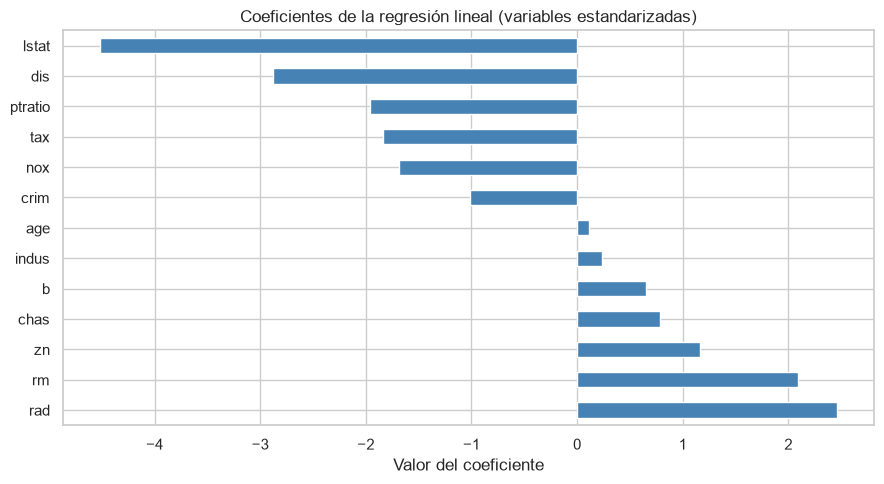

In [26]:
# Coeficientes del modelo. Al estar las variables estandarizadas, las magnitudes son
# comparables entre sí y pueden leerse como importancia relativa.
coeficientes = pd.DataFrame(
    {"coeficiente": lr.coef_}, index=X.columns
).sort_values("coeficiente", ascending=False)
display(coeficientes.round(3))
print(f"Intercepto: {lr.intercept_:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
coeficientes["coeficiente"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Coeficientes de la regresión lineal (variables estandarizadas)")
ax.set_xlabel("Valor del coeficiente")
plt.tight_layout()
plt.show()

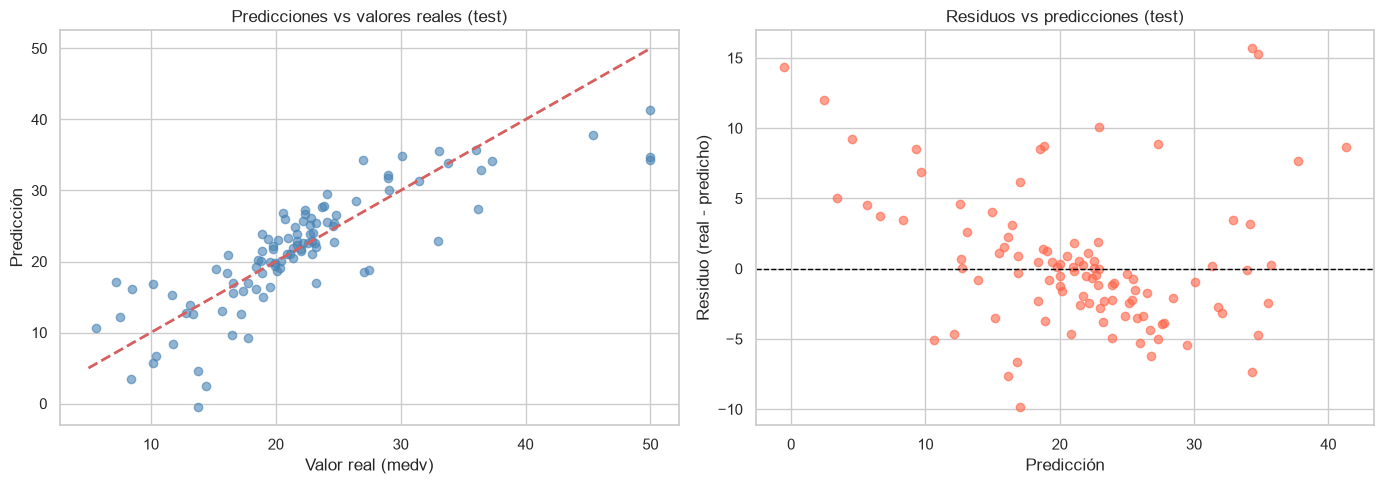

In [27]:
# Predicciones contra valores reales. Si el ajuste fuera perfecto, todos los puntos
# caerían sobre la diagonal.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred_test_lr, alpha=0.6, color="steelblue")
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
axes[0].set_xlabel("Valor real (medv)")
axes[0].set_ylabel("Predicción")
axes[0].set_title("Predicciones vs valores reales (test)")

# Residuos: si el modelo lineal fuera adecuado deberían repartirse sin estructura
# alrededor del cero.
residuos = y_test - pred_test_lr
axes[1].scatter(pred_test_lr, residuos, alpha=0.6, color="tomato")
axes[1].axhline(0, color="black", ls="--", lw=1)
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Residuo (real - predicho)")
axes[1].set_title("Residuos vs predicciones (test)")

plt.tight_layout()
plt.show()

### 3.2 Descenso del gradiente

A diferencia de la solución analítica, el descenso del gradiente parte de pesos
aleatorios y los corrige iterativamente en la dirección opuesta al gradiente de la
función de costo:

$$W \leftarrow W - \eta \, \nabla J(W), \qquad
\nabla J(W) = -\frac{2}{n} X^T (y - XW)$$

Implementamos las tres variantes, que se diferencian en cuántas muestras usan para
calcular cada actualización: **batch** (todas), **estocástico** (una) y **mini-batch**
(un grupo pequeño).

In [28]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100,
                     graficar=True, titulo="GD Batch"):
    """Regresión lineal por Descenso del Gradiente Batch.

    Usa TODAS las muestras para calcular cada actualización de los pesos.
    Devuelve los pesos W (incluido el bias) y las curvas de error.
    """
    n, m = X_train.shape
    o = X_val.shape[0]

    # Columna de unos para incorporar el término independiente (bias).
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # Inicialización aleatoria de los pesos.
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors, val_errors = [], []

    for _ in range(epochs):
        # Error y MSE sobre entrenamiento.
        error_train = y_train - np.matmul(X_train, W)
        train_errors.append(np.mean(error_train ** 2))

        # Error sobre validación: se mide pero no interviene en la actualización.
        error_val = y_val - np.matmul(X_val, W)
        val_errors.append(np.mean(error_val ** 2))

        # Gradiente del MSE y actualización de los pesos.
        gradient = (-2 / n) * np.matmul(X_train.T, error_train)
        W = W - lr * gradient

    if graficar:
        plt.figure(figsize=(11, 5))
        plt.plot(train_errors, label="Error de entrenamiento")
        plt.plot(val_errors, label="Error de validación")
        plt.xlabel("Época")
        plt.ylabel("Error cuadrático medio")
        plt.title(f"Error vs iteraciones - {titulo} (lr={lr}, epochs={epochs})")
        plt.legend()
        plt.show()

    return W, train_errors, val_errors

In [29]:
def stochastic_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01,
                                epochs=20, graficar=True):
    """Regresión lineal por Descenso del Gradiente Estocástico (SGD).

    Actualiza los pesos después de procesar CADA muestra individual.
    """
    n, m = X_train.shape

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
    y_train = np.asarray(y_train).reshape(-1, 1)
    y_val_arr = np.asarray(y_val).reshape(-1, 1)

    W = np.random.randn(m + 1).reshape(-1, 1)
    train_errors, val_errors = [], []

    for _ in range(epochs):
        # Permutación aleatoria: evita que el orden de los datos sesgue el ajuste.
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            x_sample = X_train[j].reshape(1, -1)
            y_sample = y_train[j][0]

            error = y_sample - np.matmul(x_sample, W)[0, 0]
            train_errors.append(error ** 2)

            # Gradiente calculado sobre una sola muestra.
            gradient = -2 * error * x_sample.T
            W = W - lr * gradient

        # El error de validación se mide una vez por época: hacerlo por muestra
        # multiplicaría el costo sin aportar información adicional.
        error_val = y_val_arr - np.matmul(X_val, W)
        val_errors.append(np.mean(error_val ** 2))

    if graficar:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes[0].plot(train_errors, color="steelblue", lw=0.5)
        axes[0].set_xlabel("Iteración (una por muestra)")
        axes[0].set_ylabel("Error cuadrático")
        axes[0].set_title(f"SGD - error de entrenamiento (lr={lr})")
        axes[1].plot(val_errors, color="tomato", marker="o", ms=3)
        axes[1].set_xlabel("Época")
        axes[1].set_ylabel("Error cuadrático medio")
        axes[1].set_title("SGD - error de validación")
        plt.tight_layout()
        plt.show()

    return W, train_errors, val_errors

In [30]:
def mini_batch_gradient_descent(X_train, y_train, X_val, y_val, lr=0.01,
                                epochs=100, batch_size=32, graficar=True):
    """Regresión lineal por Descenso del Gradiente Mini-Batch.

    Calcula el gradiente sobre lotes pequeños: equilibra la estabilidad del batch
    completo con la frecuencia de actualización del estocástico.
    """
    n, m = X_train.shape

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((X_val.shape[0], 1)), X_val))
    y_train = np.asarray(y_train).reshape(-1, 1)
    y_val_arr = np.asarray(y_val).reshape(-1, 1)

    W = np.random.randn(m + 1).reshape(-1, 1)
    train_errors, val_errors = [], []

    for _ in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(0, n, batch_size):
            x_batch = X_train[j:j + batch_size, :]
            y_batch = y_train[j:j + batch_size].reshape(-1, 1)

            error = y_batch - np.matmul(x_batch, W)
            train_errors.append(np.mean(error ** 2))

            # Gradiente promediado sobre el mini-batch.
            gradient = -2 * np.matmul(x_batch.T, error) / len(x_batch)
            W = W - lr * gradient

            error_val = y_val_arr - np.matmul(X_val, W)
            val_errors.append(np.mean(error_val ** 2))

    if graficar:
        plt.figure(figsize=(11, 5))
        plt.plot(train_errors, label="Error de entrenamiento", lw=0.8)
        plt.plot(val_errors, label="Error de validación", lw=0.8)
        plt.xlabel("Iteración (una por mini-batch)")
        plt.ylabel("Error cuadrático medio")
        plt.title(f"Error vs iteraciones - Mini-Batch GD "
                  f"(lr={lr}, batch_size={batch_size})")
        plt.legend()
        plt.show()

    return W, train_errors, val_errors

In [31]:
# Los targets se pasan como vectores columna, que es el formato que esperan las
# implementaciones.
y_train_col = y_train.values.reshape(-1, 1)
y_val_col = y_val.values.reshape(-1, 1)

# Función auxiliar: predice con los pesos W agregando la columna de unos.
def predecir_gd(W, X_scaled):
    X_b = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))
    return (X_b @ W).ravel()

#### Efecto del escalado sobre el descenso del gradiente

Antes de entrenar la versión definitiva mostramos por qué la estandarización no es
opcional en este algoritmo. Ejecutamos el mismo método con los datos **sin escalar**.

MSE final con datos SIN escalar y lr=0.01 : inf
¿Divergió? True


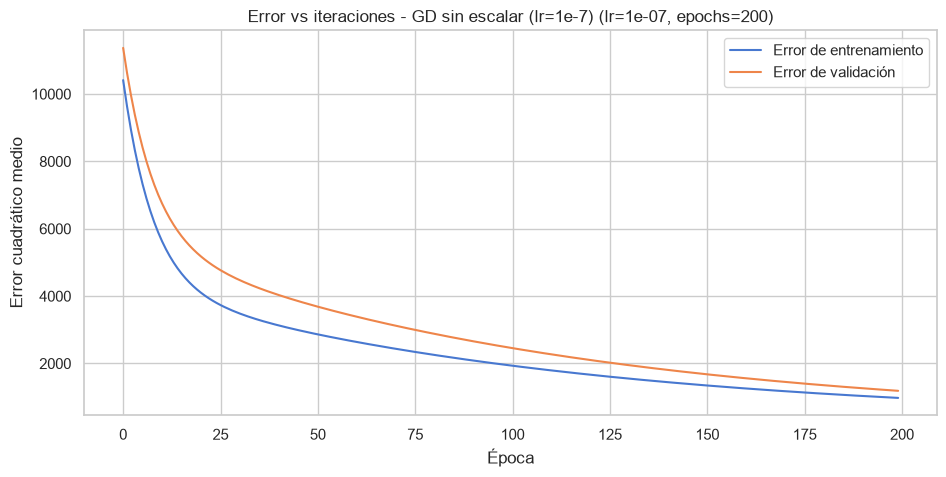

MSE final con datos SIN escalar y lr=1e-7 : 977.8511


In [32]:
# GD sobre datos SIN escalar. Con lr=0.01 el algoritmo diverge: las variables de
# escala grande (tax, b) producen gradientes enormes y cada paso sobrepasa el mínimo.
# errstate silencia los avisos de overflow de numpy, que acá son el resultado
# esperado y se informan explícitamente con el print.
np.random.seed(RANDOM_STATE)
with np.errstate(over="ignore", invalid="ignore"):
    W_sin, err_sin, _ = gradient_descent(
        X_train.values, y_train_col, X_val.values, y_val_col,
        lr=0.01, epochs=50, graficar=False,
    )
print(f"MSE final con datos SIN escalar y lr=0.01 : {err_sin[-1]:.4e}")
print(f"¿Divergió? {not np.isfinite(err_sin[-1])}")

# Para que no diverja hay que bajar la tasa de aprendizaje varios órdenes de
# magnitud. Aun así, con una lr tan chica avanza muy lento: tras 200 épocas el error
# sigue lejísimos del que se obtiene con los datos escalados (celda siguiente).
np.random.seed(RANDOM_STATE)
W_sin2, err_sin2, _ = gradient_descent(
    X_train.values, y_train_col, X_val.values, y_val_col,
    lr=1e-7, epochs=200, graficar=True, titulo="GD sin escalar (lr=1e-7)",
)
print(f"MSE final con datos SIN escalar y lr=1e-7 : {err_sin2[-1]:.4f}")

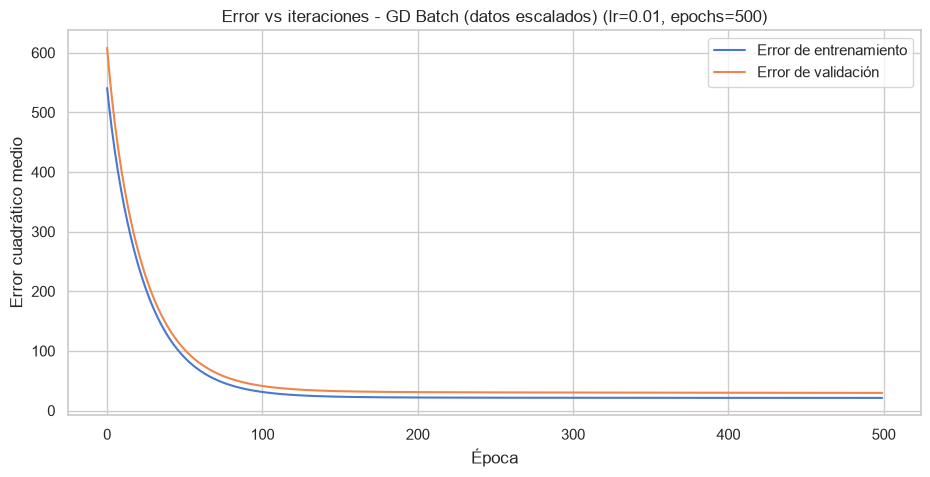

MSE final (train): 21.1895
R²   train: 0.7424   test: 0.6617
RMSE train: 4.6031   test: 4.8755


In [33]:
# GD sobre datos ESCALADOS. Con la misma lr=0.01 que antes divergía, ahora converge.
np.random.seed(RANDOM_STATE)
W_gd, err_gd_train, err_gd_val = gradient_descent(
    X_train_scaled, y_train_col, X_val_scaled, y_val_col,
    lr=0.01, epochs=500, graficar=True, titulo="GD Batch (datos escalados)",
)

pred_train_gd = predecir_gd(W_gd, X_train_scaled)
pred_test_gd = predecir_gd(W_gd, X_test_scaled)
res_gd = evaluar("GD Batch", y_train, pred_train_gd, y_test, pred_test_gd)
resultados.append(res_gd)

print(f"MSE final (train): {err_gd_train[-1]:.4f}")
print(f"R²   train: {res_gd['R2_train']:.4f}   test: {res_gd['R2_test']:.4f}")
print(f"RMSE train: {res_gd['RMSE_train']:.4f}   test: {res_gd['RMSE_test']:.4f}")

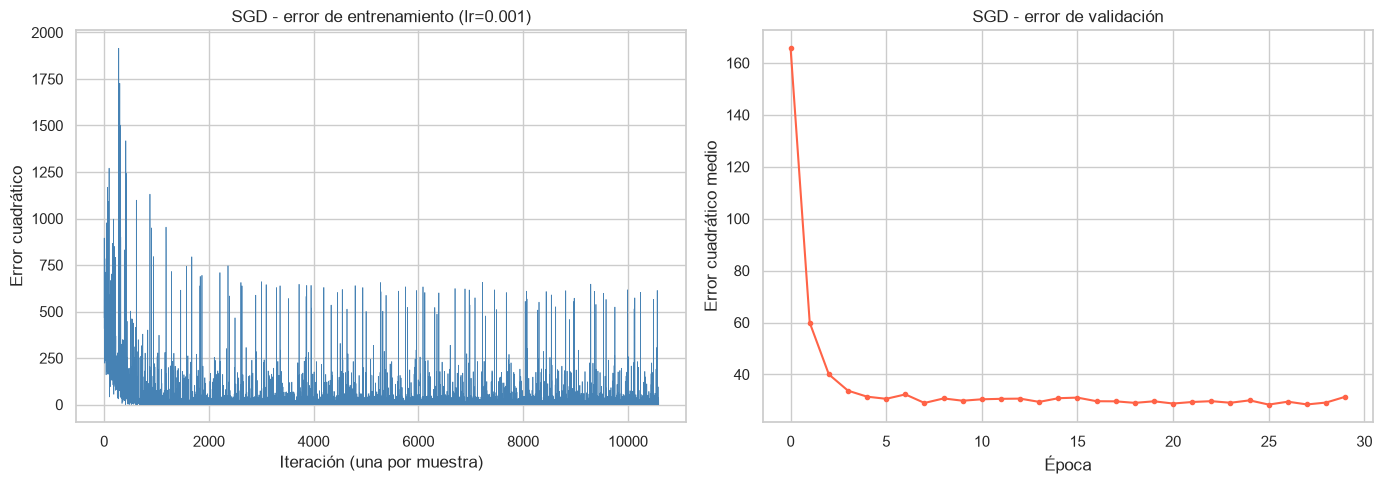

R²   train: 0.7392   test: 0.6708
RMSE train: 4.6316   test: 4.8090


In [34]:
# Descenso del gradiente estocástico sobre los datos escalados. Se usa una tasa más
# baja que en batch porque cada actualización responde a una sola muestra y una lr
# alta vuelve el recorrido inestable.
np.random.seed(RANDOM_STATE)
W_sgd, err_sgd_train, err_sgd_val = stochastic_gradient_descent(
    X_train_scaled, y_train, X_val_scaled, y_val, lr=0.001, epochs=30,
)

pred_train_sgd = predecir_gd(W_sgd, X_train_scaled)
pred_test_sgd = predecir_gd(W_sgd, X_test_scaled)
res_sgd = evaluar("GD Estocástico", y_train, pred_train_sgd, y_test, pred_test_sgd)
resultados.append(res_sgd)

print(f"R²   train: {res_sgd['R2_train']:.4f}   test: {res_sgd['R2_test']:.4f}")
print(f"RMSE train: {res_sgd['RMSE_train']:.4f}   test: {res_sgd['RMSE_test']:.4f}")

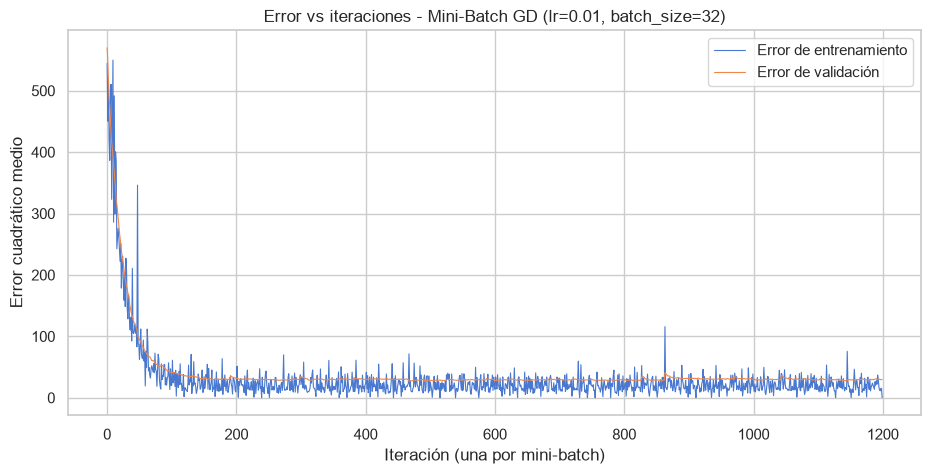

R²   train: 0.7427   test: 0.6555
RMSE train: 4.6005   test: 4.9194


In [35]:
# Descenso del gradiente mini-batch sobre los datos escalados.
np.random.seed(RANDOM_STATE)
W_mb, err_mb_train, err_mb_val = mini_batch_gradient_descent(
    X_train_scaled, y_train, X_val_scaled, y_val,
    lr=0.01, epochs=100, batch_size=32,
)

pred_train_mb = predecir_gd(W_mb, X_train_scaled)
pred_test_mb = predecir_gd(W_mb, X_test_scaled)
res_mb = evaluar("GD Mini-Batch", y_train, pred_train_mb, y_test, pred_test_mb)
resultados.append(res_mb)

print(f"R²   train: {res_mb['R2_train']:.4f}   test: {res_mb['R2_test']:.4f}")
print(f"RMSE train: {res_mb['RMSE_train']:.4f}   test: {res_mb['RMSE_test']:.4f}")

In [36]:
# Comparación de los coeficientes obtenidos por cada método contra la solución
# analítica. Si el descenso del gradiente convergió, deberían coincidir.
comparacion_W = pd.DataFrame({
    "LinearRegression": np.concatenate(([lr.intercept_], lr.coef_)),
    "GD Batch": W_gd.ravel(),
    "GD Estocástico": W_sgd.ravel(),
    "GD Mini-Batch": W_mb.ravel(),
}, index=["intercepto"] + list(X.columns))
display(comparacion_W.round(3))

,LinearRegression,GD Batch,GD Estocástico,GD Mini-Batch
intercepto,22.568,22.567,22.585,22.424
crim,-1.009,-0.896,-0.900,-1.004
zn,1.160,0.936,1.032,1.005
indus,0.238,0.041,0.181,0.009
chas,0.784,0.814,0.802,0.840
nox,-1.686,-1.368,-1.530,-1.586
rm,2.088,2.218,1.997,1.950
age,0.110,0.098,0.166,0.036
dis,-2.882,-2.497,-2.873,-2.741
rad,2.462,1.799,2.248,2.221


**¿Hay algún cambio respecto de `LinearRegression`?**

Los tres métodos iterativos llegan a coeficientes muy cercanos a los de la solución
analítica, que es el óptimo exacto. La diferencia no está en el resultado sino en
cómo se llega: `LinearRegression` resuelve el sistema de ecuaciones normales en un
paso, mientras que el descenso del gradiente se aproxima progresivamente y su
resultado depende de la tasa de aprendizaje, de la cantidad de épocas y de la
inicialización aleatoria.

La diferencia entre variantes se ve en la forma de la curva de error: el batch
desciende de manera suave porque promedia el gradiente sobre todo el conjunto; el
estocástico oscila con fuerza porque cada actualización responde a una única muestra;
el mini-batch queda en un punto intermedio.

### 3.3 Regularización: Ridge, Lasso y Elastic Net

La matriz de correlación mostró predictores fuertemente correlacionados entre sí. Esa
colinealidad infla la varianza de los coeficientes estimados. Los métodos de
regularización agregan a la función de costo un término que penaliza la magnitud de
los coeficientes:

- **Ridge (L2)**: penaliza $\sum w_i^2$. Encoge los coeficientes hacia cero sin
  anularlos.
- **Lasso (L1)**: penaliza $\sum |w_i|$. Puede llevar coeficientes exactamente a
  cero, funcionando además como selector de variables.
- **Elastic Net**: combina ambas penalizaciones mediante `l1_ratio`.

In [37]:
# Ajustamos los tres modelos regularizados con valores iniciales de alpha. En el
# punto siguiente se optimiza ese hiperparámetro.
modelos_reg = {
    "Ridge (alpha=1)": Ridge(alpha=1.0),
    "Lasso (alpha=0.1)": Lasso(alpha=0.1, max_iter=10000),
    "ElasticNet (a=0.1, l1=0.5)": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000),
}

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_scaled, y_train)
    res = evaluar(nombre, y_train, modelo.predict(X_train_scaled),
                  y_test, modelo.predict(X_test_scaled))
    resultados.append(res)
    n_cero = int(np.sum(np.abs(modelo.coef_) < 1e-10))
    print(f"{nombre}")
    print(f"   R² train: {res['R2_train']:.4f}   test: {res['R2_test']:.4f}   "
          f"RMSE test: {res['RMSE_test']:.4f}   coef. nulos: {n_cero}")

Ridge (alpha=1)
   R² train: 0.7437   test: 0.6637   RMSE test: 4.8609   coef. nulos: 0
Lasso (alpha=0.1)
   R² train: 0.7384   test: 0.6567   RMSE test: 4.9107   coef. nulos: 1
ElasticNet (a=0.1, l1=0.5)
   R² train: 0.7371   test: 0.6682   RMSE test: 4.8283   coef. nulos: 1


## 4. Optimización de hiperparámetros

### 4.1 Hiperparámetros del descenso del gradiente

lr=0.0001   MSE final: 494.3854
lr=0.001    MSE final: 246.4963
lr=0.01     MSE final: 21.8637
lr=0.1      MSE final: 21.0809
lr=0.5      MSE final: diverge


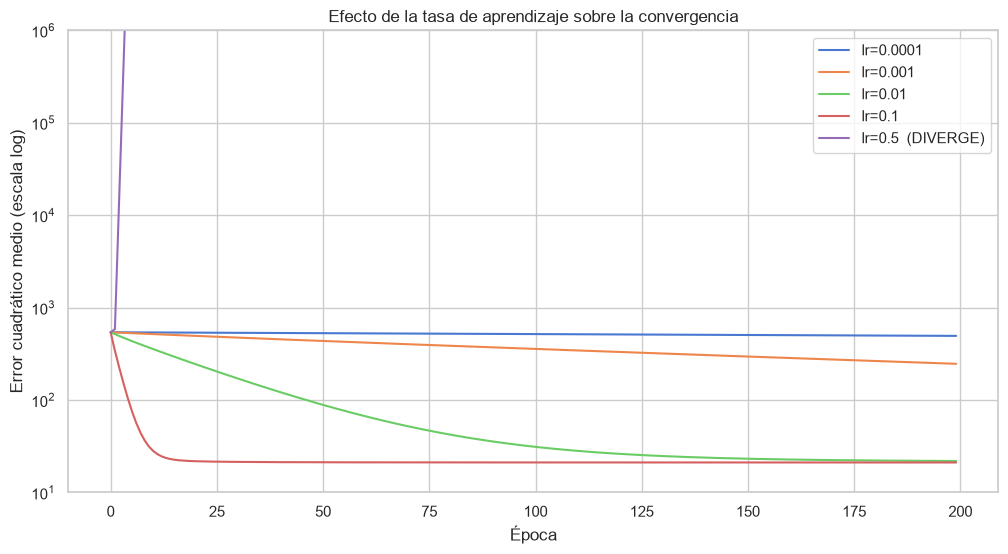

In [38]:
# Variamos la tasa de aprendizaje manteniendo fijas las épocas. Es el hiperparámetro
# más sensible del algoritmo.
tasas = [0.0001, 0.001, 0.01, 0.1, 0.5]

plt.figure(figsize=(12, 6))
for tasa in tasas:
    np.random.seed(RANDOM_STATE)
    # errstate silencia los avisos de overflow de numpy: la divergencia se detecta
    # y se informa explícitamente abajo.
    with np.errstate(over="ignore", invalid="ignore"):
        _, errores, _ = gradient_descent(
            X_train_scaled, y_train_col, X_val_scaled, y_val_col,
            lr=tasa, epochs=200, graficar=False,
        )
    # Una corrida diverge si el error final es infinito/nan o mayor que el inicial.
    # No alcanza con chequear el infinito: en 200 épocas el error puede crecer a
    # valores enormes sin llegar a desbordar.
    diverge = (not np.isfinite(errores[-1])) or errores[-1] > errores[0]
    plt.plot(errores, label=f"lr={tasa}" + ("  (DIVERGE)" if diverge else ""))
    final = "diverge" if diverge else f"{errores[-1]:.4f}"
    print(f"lr={tasa:<8} MSE final: {final}")

plt.yscale("log")   # escala log: los órdenes de magnitud entre curvas son enormes
# Se acota el eje: la curva divergente crece sin límite y aplastaría al resto.
plt.ylim(10, 1e6)
plt.xlabel("Época")
plt.ylabel("Error cuadrático medio (escala log)")
plt.title("Efecto de la tasa de aprendizaje sobre la convergencia")
plt.legend()
plt.show()

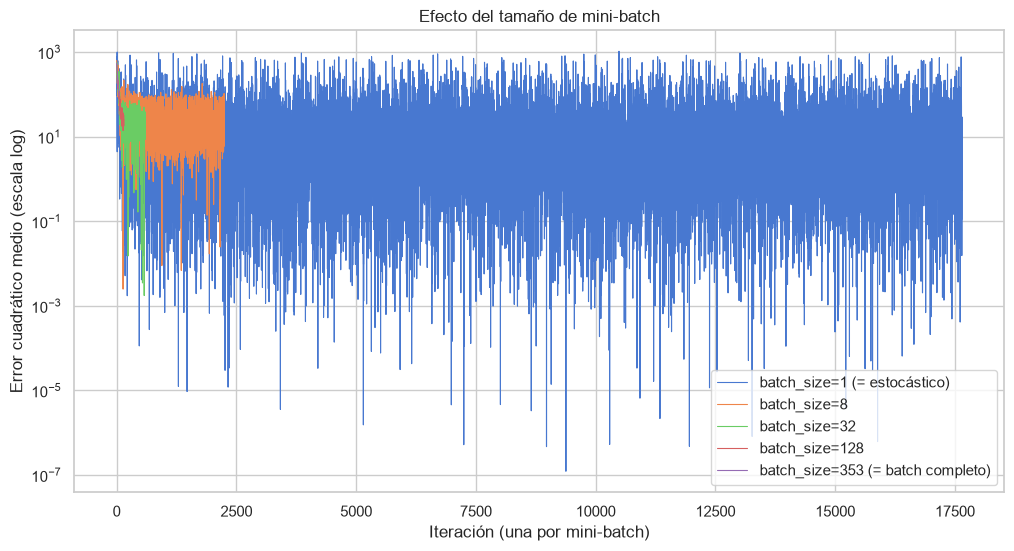

In [39]:
# Variamos el tamaño de mini-batch dejando fijas la tasa y las épocas.
tamanios = [1, 8, 32, 128, len(X_train_scaled)]

plt.figure(figsize=(12, 6))
for bs in tamanios:
    np.random.seed(RANDOM_STATE)
    _, errores, _ = mini_batch_gradient_descent(
        X_train_scaled, y_train, X_val_scaled, y_val,
        lr=0.01, epochs=50, batch_size=bs, graficar=False,
    )
    etiqueta = f"batch_size={bs}"
    if bs == 1:
        etiqueta += " (= estocástico)"
    elif bs == len(X_train_scaled):
        etiqueta += " (= batch completo)"
    plt.plot(errores, label=etiqueta, lw=0.8)

plt.yscale("log")
plt.xlabel("Iteración (una por mini-batch)")
plt.ylabel("Error cuadrático medio (escala log)")
plt.title("Efecto del tamaño de mini-batch")
plt.legend()
plt.show()

**¿Qué se observa al variar los hiperparámetros del descenso del gradiente?**

- Con una **tasa de aprendizaje baja** (`lr=0.0001` y `lr=0.001`) el algoritmo avanza
  en la dirección correcta, pero tan despacio que al agotarse las 200 épocas todavía
  está lejos del mínimo: el error final es alto por falta de iteraciones, no por un
  defecto del método.
- Con una **tasa intermedia** (`lr=0.01`, `lr=0.1`) la convergencia es rápida y
  estable, y ambas llegan a un MSE cercano al de la solución analítica.
- Con una **tasa demasiado alta** (`lr=0.5`) cada paso sobrepasa el mínimo y lo
  sobrecorrige: el error crece en lugar de bajar, de forma exponencial.
- El **tamaño del mini-batch** controla el compromiso entre ruido y costo por
  actualización. Con `batch_size=1` la curva es muy ruidosa porque cada paso responde
  a una única muestra; con el batch completo la curva es suave, pero hay una sola
  actualización por época y el avance por unidad de cómputo es menor.
- El escalado previo cambia por completo el rango de tasas utilizable: sin
  estandarizar hubo que bajar `lr` varios órdenes de magnitud para evitar la
  divergencia.

### 4.2 Hiperparámetros de Ridge, Lasso y Elastic Net

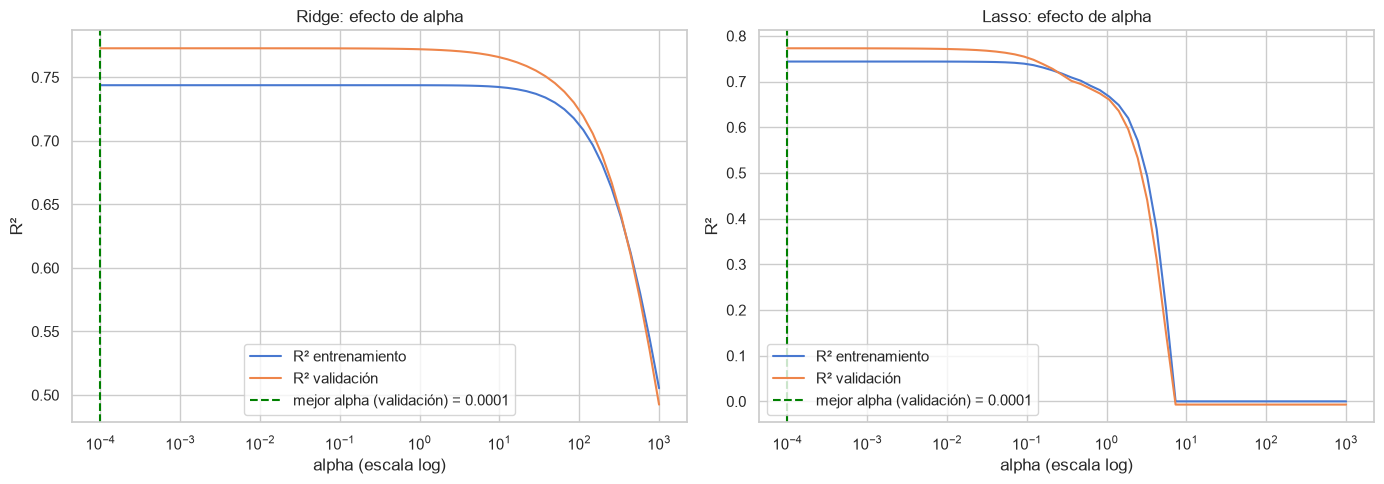

In [40]:
# Barremos alpha en escala logarítmica y observamos cómo evoluciona el desempeño en
# entrenamiento y en VALIDACIÓN. alpha controla la fuerza de la penalización.
# El conjunto de prueba no se usa acá: elegir un hiperparámetro mirándolo haría que
# las métricas de test dejaran de medir generalización.
alphas = np.logspace(-4, 3, 60)

curvas = {"Ridge": [], "Lasso": []}
for a in alphas:
    for nombre, modelo in [("Ridge", Ridge(alpha=a)),
                           ("Lasso", Lasso(alpha=a, max_iter=10000))]:
        modelo.fit(X_train_scaled, y_train)
        curvas[nombre].append((
            r2_score(y_train, modelo.predict(X_train_scaled)),
            r2_score(y_val, modelo.predict(X_val_scaled)),
        ))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, nombre in zip(axes, ["Ridge", "Lasso"]):
    r2_tr = [c[0] for c in curvas[nombre]]
    r2_va = [c[1] for c in curvas[nombre]]
    ax.semilogx(alphas, r2_tr, label="R² entrenamiento")
    ax.semilogx(alphas, r2_va, label="R² validación")
    mejor_alpha = alphas[int(np.argmax(r2_va))]
    ax.axvline(mejor_alpha, color="green", ls="--",
               label=f"mejor alpha (validación) = {mejor_alpha:.4f}")
    ax.set_xlabel("alpha (escala log)")
    ax.set_ylabel("R²")
    ax.set_title(f"{nombre}: efecto de alpha")
    ax.legend()
plt.tight_layout()
plt.show()

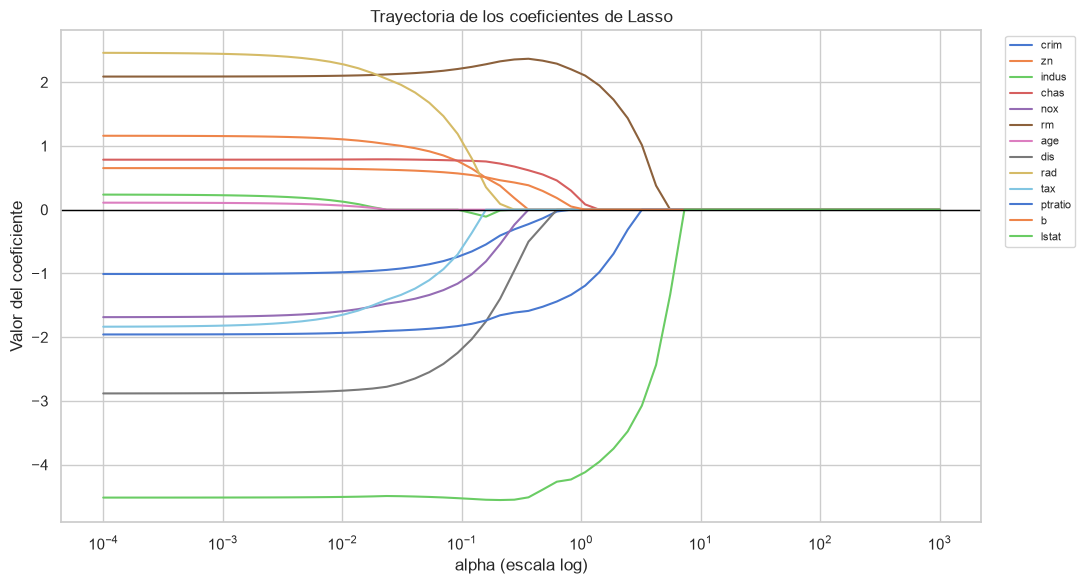

Coeficientes anulados por Lasso según alpha:
  alpha=    0.0001 -> 0 de 13 coeficientes en cero
  alpha=    0.0015 -> 0 de 13 coeficientes en cero
  alpha=    0.0236 -> 1 de 13 coeficientes en cero
  alpha=    0.3625 -> 6 de 13 coeficientes en cero
  alpha=    5.5688 -> 12 de 13 coeficientes en cero
  alpha=   85.5467 -> 13 de 13 coeficientes en cero


In [41]:
# Trayectoria de los coeficientes de Lasso al aumentar alpha. Se ve cómo se van
# anulando uno por uno: eso es la selección de variables que caracteriza a L1.
coefs_lasso = []
for a in alphas:
    m = Lasso(alpha=a, max_iter=10000).fit(X_train_scaled, y_train)
    coefs_lasso.append(m.coef_)
coefs_lasso = np.array(coefs_lasso)

plt.figure(figsize=(11, 6))
for i, col in enumerate(X.columns):
    plt.semilogx(alphas, coefs_lasso[:, i], label=col)
plt.axhline(0, color="black", lw=1)
plt.xlabel("alpha (escala log)")
plt.ylabel("Valor del coeficiente")
plt.title("Trayectoria de los coeficientes de Lasso")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

# Cantidad de coeficientes anulados en función de alpha.
n_nulos = (np.abs(coefs_lasso) < 1e-10).sum(axis=1)
print("Coeficientes anulados por Lasso según alpha:")
for a, n in zip(alphas[::10], n_nulos[::10]):
    print(f"  alpha={a:10.4f} -> {n} de {len(X.columns)} coeficientes en cero")

In [42]:
# Selección automática de alpha por validación cruzada de 5 pliegues. Es el método
# correcto: elegir el hiperparámetro mirando el conjunto de prueba lo invalidaría
# como estimación de generalización.
ridge_cv = RidgeCV(alphas=alphas, cv=5).fit(X_train_scaled, y_train)
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000,
                   random_state=RANDOM_STATE).fit(X_train_scaled, y_train)
elastic_cv = ElasticNetCV(alphas=alphas, l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                          cv=5, max_iter=10000,
                          random_state=RANDOM_STATE).fit(X_train_scaled, y_train)

print(f"RidgeCV      -> alpha óptimo: {ridge_cv.alpha_:.5f}")
print(f"LassoCV      -> alpha óptimo: {lasso_cv.alpha_:.5f}")
print(f"ElasticNetCV -> alpha óptimo: {elastic_cv.alpha_:.5f}, "
      f"l1_ratio óptimo: {elastic_cv.l1_ratio_}")
print()

for nombre, modelo in [("RidgeCV", ridge_cv), ("LassoCV", lasso_cv),
                       ("ElasticNetCV", elastic_cv)]:
    res = evaluar(nombre, y_train, modelo.predict(X_train_scaled),
                  y_test, modelo.predict(X_test_scaled))
    resultados.append(res)
    print(f"{nombre:13s} R² train: {res['R2_train']:.4f}   "
          f"test: {res['R2_test']:.4f}   RMSE test: {res['RMSE_test']:.4f}")

RidgeCV      -> alpha óptimo: 21.82645
LassoCV      -> alpha óptimo: 0.02360
ElasticNetCV -> alpha óptimo: 0.07038, l1_ratio óptimo: 0.1

RidgeCV       R² train: 0.7391   test: 0.6722   RMSE test: 4.7987
LassoCV       R² train: 0.7433   test: 0.6623   RMSE test: 4.8707
ElasticNetCV  R² train: 0.7385   test: 0.6720   RMSE test: 4.8000


**¿Qué se observa al variar los hiperparámetros de Lasso y Ridge?**

- Con **alpha cercano a cero** la penalización es despreciable y ambos modelos
  reproducen la regresión lineal sin regularizar.
- A medida que **alpha crece**, el R² de entrenamiento baja de forma monótona: la
  penalización impide que el modelo se ajuste tanto a los datos vistos. El R² de
  validación, en cambio, primero se mantiene o mejora levemente y recién después cae.
  Esa zona intermedia es donde la regularización aporta: cambia un poco de sesgo por
  una reducción de varianza.
- Con **alpha muy grande** los coeficientes se aplastan contra cero y el modelo pierde
  capacidad de explicar: es un caso de alto sesgo.
- La diferencia entre ambos está en *cómo* encogen. Ridge reduce todos los
  coeficientes de forma gradual pero nunca los anula. Lasso los lleva a cero uno por
  uno, y por eso funciona además como selector de variables.
- Lasso es mucho más sensible a alpha que Ridge: su R² se desploma a partir de
  alpha ≈ 1, mientras que Ridge tolera valores cientos de veces mayores. Por eso el
  alpha óptimo de Ridge resulta mucho más grande que el de Lasso.
- En validación la curva queda prácticamente plana hasta que la penalización empieza
  a pesar, de modo que su máximo cae en el extremo izquierdo del barrido: con estos
  datos la regularización no mejora de forma visible sobre el modelo sin penalizar.
  Pero el conjunto de validación tiene solo 51 filas y es una estimación ruidosa (de
  hecho su R² queda por encima del de entrenamiento, algo que en un conjunto tan chico
  puede pasar por azar). Por eso la elección definitiva de alpha se hace con
  validación cruzada de 5 pliegues, que promedia sobre todo el conjunto de
  entrenamiento.

## 5. Comparación de modelos

Elegimos el **RMSE sobre el conjunto de prueba** como métrica principal de
comparación. La razón es que está expresado en las mismas unidades que el target
(miles de dólares), lo que lo hace interpretable, y penaliza con más fuerza los
errores grandes, que en una tasación son los más costosos. Reportamos también el R²
como medida relativa adimensional, y el MAE como referencia menos sensible a valores
extremos.

In [43]:
# Tabla comparativa de todos los modelos entrenados, ordenada por RMSE de prueba.
tabla_final = (
    pd.DataFrame(resultados).set_index("modelo").sort_values("RMSE_test").round(4)
)
# Brecha entre train y test: cuanto mayor, más sobreajuste.
tabla_final["brecha_R2"] = (tabla_final["R2_train"] - tabla_final["R2_test"]).round(4)
display(tabla_final)

mejor = tabla_final.index[0]
print(f"Mejor modelo según RMSE de prueba: {mejor}")
print(f"  RMSE test: {tabla_final.loc[mejor, 'RMSE_test']:.4f} k$")
print(f"  R² test  : {tabla_final.loc[mejor, 'R2_test']:.4f}")

,R2_train,R2_test,RMSE_train,RMSE_test,MAE_train,MAE_test,brecha_R2
modelo,,,,,,,
RidgeCV,0.7391,0.6722,4.6330,4.7987,3.1282,3.4215,0.0669
ElasticNetCV,0.7385,0.6720,4.6379,4.8000,3.1288,3.4220,0.0665
GD Estocástico,0.7392,0.6708,4.6316,4.8090,3.2240,3.4083,0.0684
"ElasticNet (a=0.1, l1=0.5)",0.7371,0.6682,4.6505,4.8283,3.1383,3.4406,0.0689
Ridge (alpha=1),0.7437,0.6637,4.5914,4.8609,3.1721,3.4760,0.0800
LinearRegression,0.7438,0.6630,4.5912,4.8656,3.1773,3.4794,0.0808
LassoCV,0.7433,0.6623,4.5956,4.8707,3.1656,3.4802,0.0810
GD Batch,0.7424,0.6617,4.6031,4.8755,3.1570,3.4867,0.0807
Lasso (alpha=0.1),0.7384,0.6567,4.6391,4.9107,3.1655,3.4858,0.0817


Mejor modelo según RMSE de prueba: RidgeCV
  RMSE test: 4.7987 k$
  R² test  : 0.6722


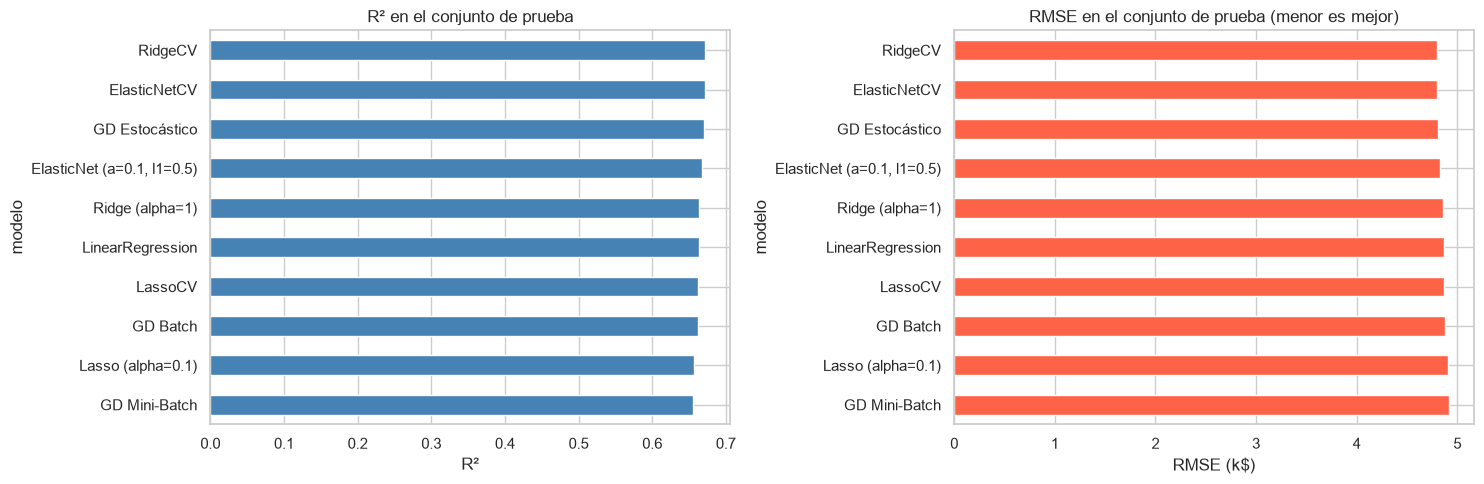

In [44]:
# Comparación visual de R² y RMSE sobre el conjunto de prueba.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tabla_final["R2_test"].sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("R² en el conjunto de prueba")
axes[0].set_xlabel("R²")

tabla_final["RMSE_test"].sort_values(ascending=False).plot(
    kind="barh", ax=axes[1], color="tomato")
axes[1].set_title("RMSE en el conjunto de prueba (menor es mejor)")
axes[1].set_xlabel("RMSE (k$)")

plt.tight_layout()
plt.show()

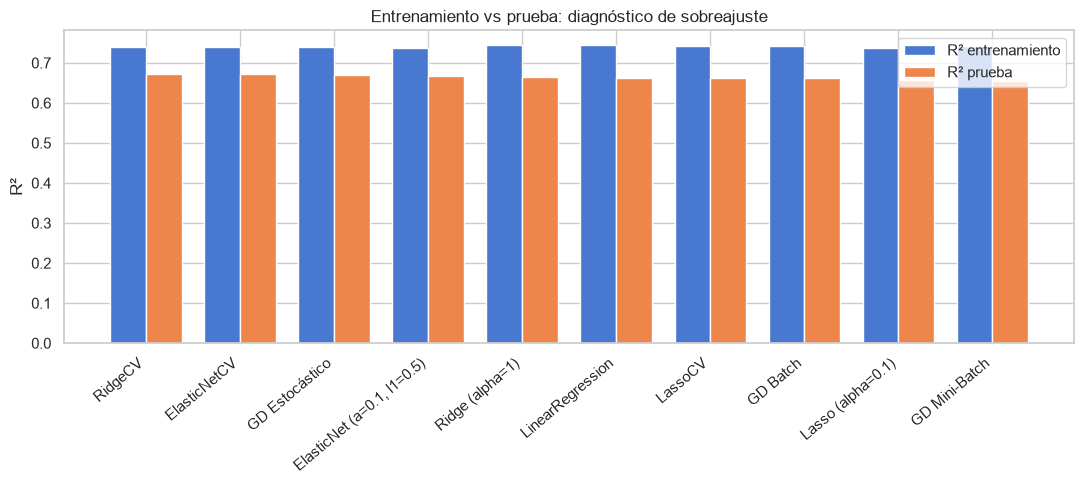

In [45]:
# Entrenamiento contra prueba, para diagnosticar sobreajuste modelo por modelo.
fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(tabla_final))
ancho = 0.38
ax.bar(x_pos - ancho/2, tabla_final["R2_train"], ancho, label="R² entrenamiento")
ax.bar(x_pos + ancho/2, tabla_final["R2_test"], ancho, label="R² prueba")
ax.set_xticks(x_pos)
ax.set_xticklabels(tabla_final.index, rotation=40, ha="right")
ax.set_ylabel("R²")
ax.set_title("Entrenamiento vs prueba: diagnóstico de sobreajuste")
ax.legend()
plt.tight_layout()
plt.show()

### ¿Conseguimos un buen ajuste?

Para responderlo hay que mirar las dos métricas juntas, no una sola. Un R² alto en
entrenamiento no dice nada por sí mismo: un modelo que memorice los datos vistos
puede alcanzar R² = 1 en train y ser inútil sobre datos nuevos. Por eso las métricas
se calculan sobre **ambos conjuntos**:

- Si el modelo anda **mal en train y mal en test**, el problema es de **sesgo**: es
  demasiado simple para el fenómeno.
- Si anda **muy bien en train y mal en test**, el problema es de **varianza**: se
  sobreajustó a los datos de entrenamiento.
- Si anda **parecido en ambos**, generaliza.

En este trabajo la brecha entre el R² de entrenamiento y el de prueba es chica en
todos los modelos lineales (del orden de 0.07 a 0.09), lo que indica que no hay
sobreajuste apreciable. Es lo esperable: un modelo lineal con 13 predictores y varios
cientos de observaciones tiene poca capacidad de memorizar. El límite acá no es la
varianza sino el sesgo. El gráfico de residuos lo respalda: forman una curva en U en
lugar de repartirse al azar alrededor del cero, lo que indica que la relación entre
algunas variables y el target no es estrictamente lineal y fija un techo al R²
alcanzable con este tipo de modelo. Otro síntoma de la misma limitación es que el
modelo llega a predecir un precio levemente negativo para una vivienda del conjunto
de prueba, algo imposible en la realidad.

**Conclusión:** el ajuste es aceptable (R² de prueba ≈ 0.67, error típico de unos
4.8 k$) y sin sobreajuste, pero el modelo está algo subajustado por su linealidad.

## 6. Conclusiones

**Sobre el tratamiento de los datos faltantes.** El análisis por fila mostró que la
faltancia no era el problema sino el síntoma. Las filas incompletas resultaron
contener valores observados imposibles —decimales en `rad` y `tax`, que son enteras
en todas las filas completas— y el 100% de las filas auditables falló ese test.
Imputarlas habría significado fabricar observaciones sobre registros ya corrompidos.
La decisión de descartarlas se apoya en evidencia interna del propio dataset, no en
la conveniencia de no tener que imputar.

**Sobre los outliers.** Se mantuvieron. Son valores plausibles del fenómeno (barrios
con criminalidad muy alta, viviendas muy grandes, el tope de 50 k$ de `medv`) y no
errores de carga; además, descartar toda fila con algún outlier habría eliminado
casi la mitad del dataset.

**Sobre los métodos de resolución.** `LinearRegression` y las tres variantes de
descenso del gradiente convergen esencialmente a la misma solución, lo cual es
esperable: resuelven el mismo problema de optimización sobre una función de costo
convexa, que tiene un único mínimo. La solución analítica es preferible en este caso
por ser exacta y no requerir ajuste de hiperparámetros; el descenso del gradiente
cobra sentido cuando el volumen de datos vuelve inviable invertir la matriz $X^TX$.

**Sobre el escalado.** Fue determinante para los métodos iterativos. Sin
estandarizar, el descenso del gradiente necesitó una tasa de aprendizaje varios
órdenes de magnitud menor para no divergir. Para `LinearRegression` el escalado no
cambia las predicciones, pero vuelve comparables los coeficientes entre sí y permite
leerlos como importancia relativa.

**Sobre la regularización.** Su aporte en términos de error de prueba fue marginal,
lo cual es coherente con el diagnóstico anterior: la regularización combate la
varianza, y acá el modelo no estaba sobreajustando. Su valor fue más bien
diagnóstico: la trayectoria de coeficientes de Lasso mostró qué variables sobreviven
al aumentar la penalización y cuáles son las primeras en anularse.

**Sobre las variables.** Tomadas de a una, `lstat` y `rm` son las más asociadas al
precio (correlaciones de −0.74 y +0.70). En el modelo multivariado `lstat` sigue
siendo el coeficiente de mayor magnitud, pero `rm` queda detrás de `dis` y `rad`. No
es una contradicción: el coeficiente mide el efecto de una variable *manteniendo
fijas las demás*, y parte de la información de `rm` ya la aportan otras variables
correlacionadas con ella. Por el mismo motivo, `rad` y `tax` (correlación 0.91 entre
sí) reciben coeficientes de signo opuesto aunque ambas se asocian negativamente con
el precio: la colinealidad vuelve inestables sus coeficientes y no conviene
interpretarlos por separado.

**Limitaciones y trabajo futuro.**

- El detector de corrupción se apoya en las únicas dos variables enteras del dataset;
  filas alteradas solo en variables continuas serían indetectables por esta vía.
- Los residuos sugieren que la relación no es perfectamente lineal. Explorar
  `PolynomialFeatures` permitiría capturar curvatura sin abandonar el marco lineal.
- `medv` está censurada en 50 k$: para esas viviendas el modelo aprende un tope y no
  el precio real, lo que limita el desempeño en el segmento más caro.
- El conjunto de prueba es de tamaño acotado, de modo que las diferencias pequeñas de
  RMSE entre modelos no son necesariamente significativas. Una validación cruzada
  sobre todo el conjunto daría una comparación más estable, con una media y un desvío
  por modelo en lugar de un único número.